In [1]:

import networkx as nx
from tigramite import plotting as tp
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests import ParCorr, GPDC, CMIknn, CMIsymb
from tigramite.models import LinearMediation, Prediction

import tigramite
from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests import ParCorr, GPDC, CMIknn, CMIsymb
from tigramite.models import LinearMediation, Prediction

tp.nx = nx

c:\Users\yinglint\AppData\Local\anaconda3\envs\myenv39\lib\site-packages\tigramite\plotting.py:26: UserWarning: [Errno 2] No such file or directory: 'c:\\Users\\yinglint\\AppData\\Local\\anaconda3\\envs\\myenv39\\lib\\site-packages\\tigramite\\..\\versions.py'
  warnings.warn(str(e))
c:\Users\yinglint\AppData\Local\anaconda3\envs\myenv39\lib\site-packages\tigramite\independence_tests\gpdc.py:27: UserWarning: No module named 'dcor'
  warnings.warn(str(e))
c:\Users\yinglint\AppData\Local\anaconda3\envs\myenv39\lib\site-packages\tigramite\independence_tests\gpdc_torch.py:33: UserWarning: No module named 'dcor'
  warnings.warn(str(e))
c:\Users\yinglint\AppData\Local\anaconda3\envs\myenv39\lib\site-packages\tigramite\models.py:29: UserWarning: [Errno 2] No such file or directory: 'c:\\Users\\yinglint\\AppData\\Local\\anaconda3\\envs\\myenv39\\lib\\site-packages\\tigramite\\..\\versions.py'
  warnings.warn(str(e))


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

import copy
from netCDF4 import Dataset, num2date, date2num

In [3]:

import more_itertools as mit
# from scipy import arange, cos, exp
from scipy.interpolate import RegularGridInterpolator
from numpy import unique
from numpy import where
from sklearn.datasets import make_classification
from sklearn.cluster import KMeans
from sklearn import datasets
from sklearn import metrics
from matplotlib import pyplot
import matplotlib.patches as patches
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

from scipy.stats import theilslopes
from statsmodels.nonparametric.smoothers_lowess import lowess

In [4]:

# import cartopy.feature as cf
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl

from scipy.stats import rankdata
from scipy.stats import linregress
from scipy import signal

import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import matplotlib.patches as mpatches

## FWI

In [5]:

NCData = Dataset(r'D:/from_PIK/data/ERA5_globe/land_sea_mask_2023_01_01_1x1.nc')
land_mask = np.squeeze(NCData.variables['var172'][:])
lon_era5= NCData.variables['lon'][:][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
print(NCData.variables['lon'][:][:][:10])
print(NCData.variables['lat'][:][:][:10])
NCData.close()

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[90. 89. 88. 87. 86. 85. 84. 83. 82. 81.]


In [6]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'D:/from_PIK/data/ERA5_globe_1950_2025/ERA5_1950_2025_FWI_cal_1.x1._3daymean.nc') #current shape = (365, 180,360)

FWI = np.squeeze(NCData.variables['FWI'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

NCData.close()

In [7]:
temp = np.nanmean(FWI,axis=0)
temp[land_mask<0.3]=np.nan

In [8]:
lon_min, lon_max = -10, 40
lat_min, lat_max = 35, 46

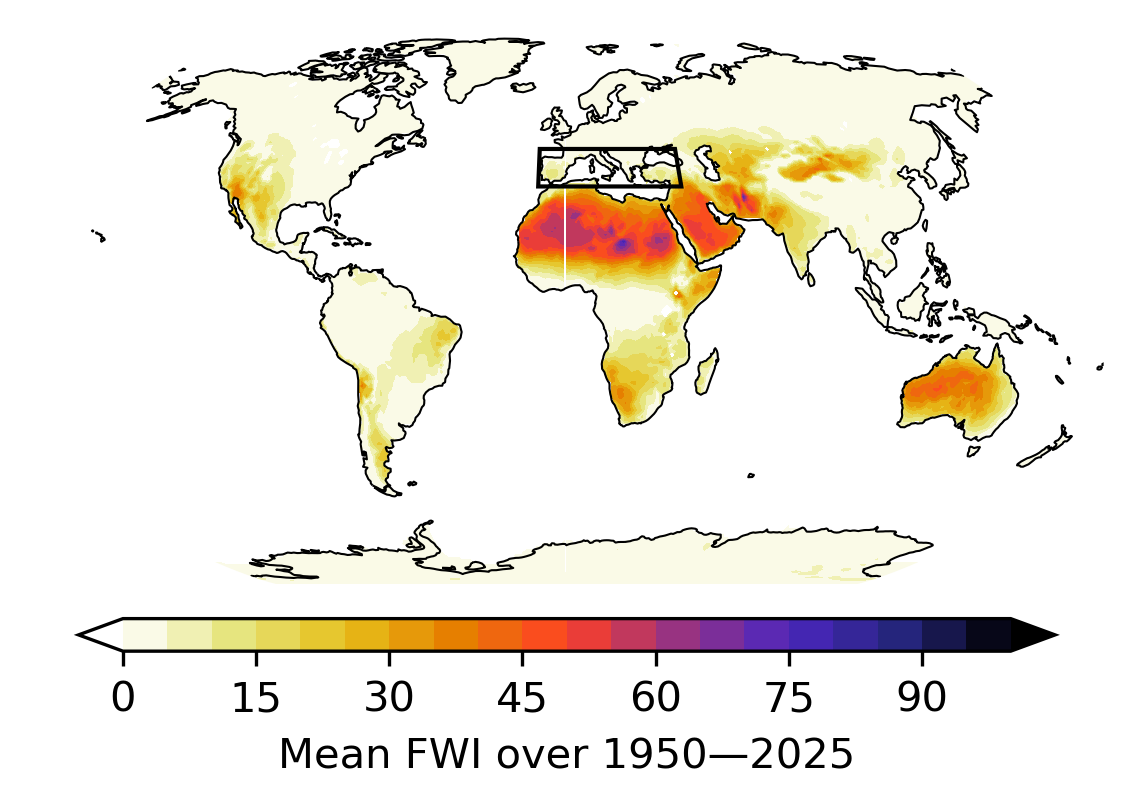

In [9]:
import matplotlib.patches as mpatches
# 绘图
fig, ax = plt.subplots(figsize=(6,3), subplot_kw={'projection': ccrs.Robinson()},dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(0,105,5)
contour = ax.contourf(
    LON_era5,LAT_era5,temp,
    levels=levels,
    transform=ccrs.PlateCarree(),  
    cmap='CMRmap_r',
    extend='both'
)

rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.add_patch(rect)

ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=30)
co.set_label(r'Mean FWI over 1950—2025')
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
# ax.set_title('ERA5')
ax.axis('off')
plt.show()

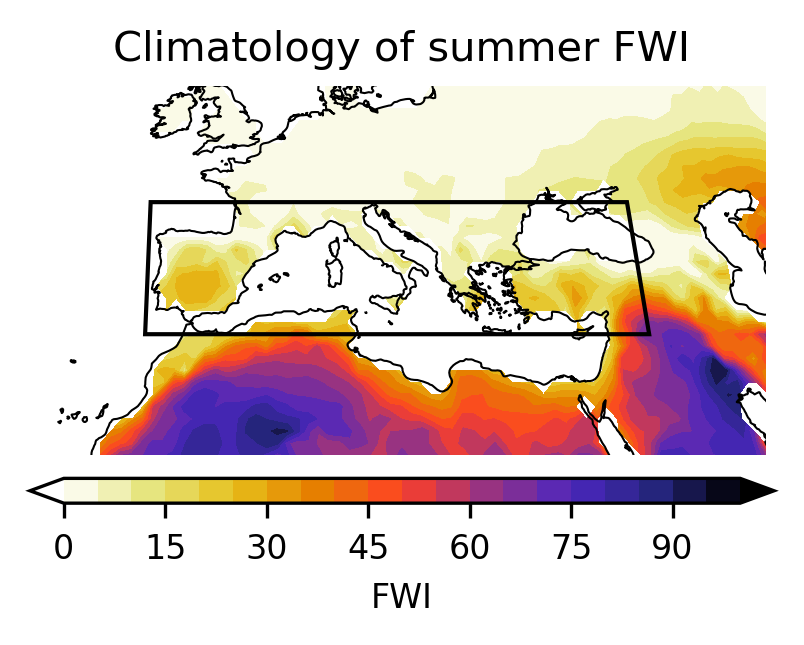

In [10]:
temp_JJA = np.nanmean(FWI[np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,range(1979,2026))],axis=0)
temp_JJA[land_mask<0.3]=np.nan
temp_cyclic, lon_cyclic = add_cyclic_point(temp_JJA, coord=LON_era5[0, :])
lon2d, lat2d = np.meshgrid(lon_cyclic, LAT_era5[:, 0])

import matplotlib.patches as mpatches
# 绘图
fig, ax = plt.subplots(figsize=(4,2), subplot_kw={'projection': ccrs.Robinson()},dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(0,105,5)
contour = ax.contourf(
    lon2d,lat2d,temp_cyclic,
    levels=levels,
    transform=ccrs.PlateCarree(),  
    cmap='CMRmap_r',
    extend='both'
)

rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.add_patch(rect)

ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8, aspect=30)
co.set_label(r'FWI',fontsize=8)
co.ax.tick_params(labelsize=8)
ax.set_extent([lon_min-10, lon_max+10, lat_min-10, lat_max+10], crs=ccrs.PlateCarree())
ax.set_title(r'Climatology of summer FWI',fontsize=10)
ax.axis('off')
plt.show()

In [11]:
temp_JJA_yearly = []
for i_year in range(1979,2026):
    temp_JJA_yearly.append(np.nanmean(FWI[np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,i_year)],axis=0))

temp_JJA_yearly = np.array(temp_JJA_yearly)

temp_JJA_yearly_trend = np.zeros((temp_JJA_yearly.shape[1],temp_JJA_yearly.shape[2]))
temp_JJA_yearly_p = np.zeros((temp_JJA_yearly.shape[1],temp_JJA_yearly.shape[2]))

for i_lat in range(temp_JJA_yearly.shape[1]):
    for i_lon in  range(temp_JJA_yearly.shape[2]):
        temp = temp_JJA_yearly[:,i_lat,i_lon]
        slope, intercept, r, p, stderr = linregress( range(1979,2026),temp)
        temp_JJA_yearly_trend[i_lat,i_lon] = slope
        temp_JJA_yearly_p[i_lat,i_lon] = p


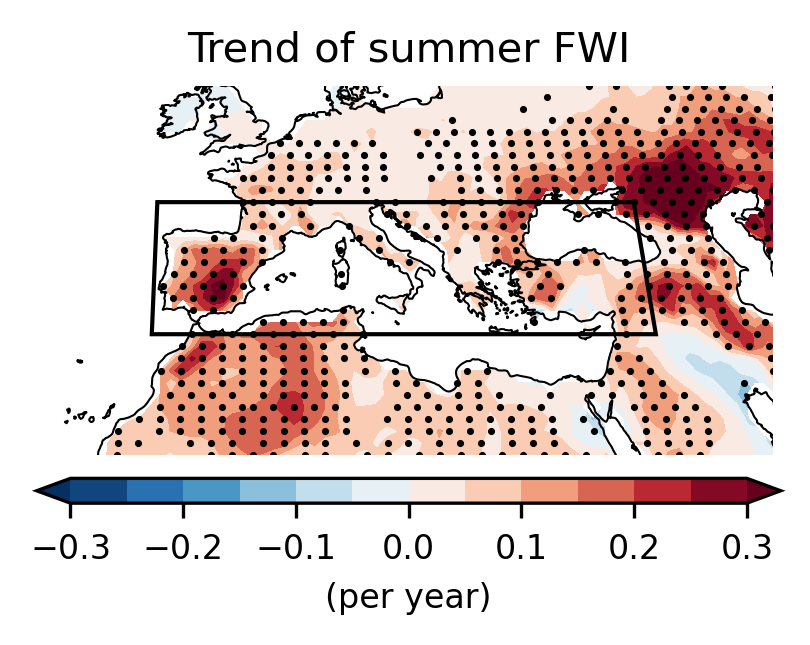

In [12]:


temp_JJA_yearly_trend[land_mask<0.3]=np.nan
temp_JJA_yearly_p[land_mask<0.3]=np.nan
temp_cyclic, lon_cyclic = add_cyclic_point(temp_JJA_yearly_trend, coord=LON_era5[0, :])
lon2d, lat2d = np.meshgrid(lon_cyclic, LAT_era5[:, 0])
import matplotlib.patches as mpatches
# 绘图
fig, ax = plt.subplots(figsize=(4,2), subplot_kw={'projection': ccrs.Robinson()},dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(-0.3,0.35,0.05)
contour = ax.contourf(
    lon2d, lat2d ,temp_cyclic,
 levels=levels,
    transform=ccrs.PlateCarree(),  
    cmap='RdBu_r',
    extend='both'
)

ax.scatter(
    LON_era5[temp_JJA_yearly_p<0.05][::2],LAT_era5[temp_JJA_yearly_p<0.05][::2],c='k', s=0.5,transform=ccrs.PlateCarree(),)

rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.add_patch(rect)

ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8, aspect=30)
co.set_label(r'(per year)',fontsize=8)
co.ax.tick_params(labelsize=8)
ax.set_extent([lon_min-10, lon_max+10, lat_min-10, lat_max+10], crs=ccrs.PlateCarree())
ax.set_title(r'Trend of summer FWI',fontsize=10)
ax.axis('off')
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Inputs you already have:
#   FWI:        (time, lat, lon)  or (time, y, x)
#   LAT_era5:   (lat, lon)        or (y, x)
#   LON_era5:   (lat, lon)        or (y, x) in 0..360
#   land_mask:  (lat, lon)        or (y, x)  (0..1)
# -----------------------------

# -----------------------------
# 1) Define region (lon in -180..180 convention)
# -----------------------------
lon_min, lon_max = -10, 40
lat_min, lat_max = 35, 46
land_thr = 0.3

# Convert 0..360 lon -> -180..180
LON_era5_180 = ((LON_era5 + 180) % 360) - 180

# Region + land mask (2D boolean mask)
region_mask = (
    (LAT_era5 >= lat_min) & (LAT_era5 <= lat_max) &
    (LON_era5_180 >= lon_min) & (LON_era5_180 <= lon_max) &
    (land_mask >= land_thr)
)
time_mask = (np.in1d(mon_era5_all,[6,7,8]))
# -----------------------------
# 2) Extract spatio-temporal data for clustering
# -----------------------------
# Shape: (time, Npoints_in_region)
FWI_region = FWI[time_mask,:][:, region_mask]

# Optional: remove points that are all-NaN across time
valid_pt = ~np.all(np.isnan(FWI_region), axis=0)
FWI_region = FWI_region[:, valid_pt]

lat_region = LAT_era5[region_mask][valid_pt]
lon_region = LON_era5_180[region_mask][valid_pt]

# Features for KMeans: each grid cell is a sample, with time-series as features
# Shape: (Npoints, time)
X = FWI_region.T

# KMeans cannot handle NaNs: fill remaining NaNs with per-point mean (or 0)
# Here: fill with each point's temporal mean (more conservative than 0)
pt_mean = np.nanmean(X, axis=1, keepdims=True)
X_filled = np.where(np.isnan(X), pt_mean, X)

# Standardize features (important for time-series clustering)
# X_std = StandardScaler().fit_transform(X_filled)



In [63]:
time_mask = (np.in1d(mon_era5_all,[6,7,8]))
year_era5_all_JJA = year_era5_all[time_mask ]
mon_era5_all_JJA = mon_era5_all[time_mask ]
day_era5_all_JJA = day_era5_all[time_mask ]

In [15]:



X_std = copy.deepcopy(X_filled )
for i_mon in set(mon_era5_all_JJA):
    mu  = np.nanmean(X_std[:,mon_era5_all_JJA==i_mon] , axis=1, keepdims=True)
    X_std[:,mon_era5_all_JJA==i_mon] = X_std[:,mon_era5_all_JJA==i_mon] -mu

mu  = np.nanmean(X_std, axis=1, keepdims=True)
sig = np.nanstd(X_std, axis=1, keepdims=True)

X_std_grid = (X_std - mu) /sig


c:\Users\yinglint\AppData\Local\anaconda3\envs\myenv39\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\yinglint\AppData\Local\anaconda3\envs\myenv39\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\yinglint\AppData\Local\anaconda3\envs\myenv39\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\yinglint\AppData\Local\anaconda3\envs

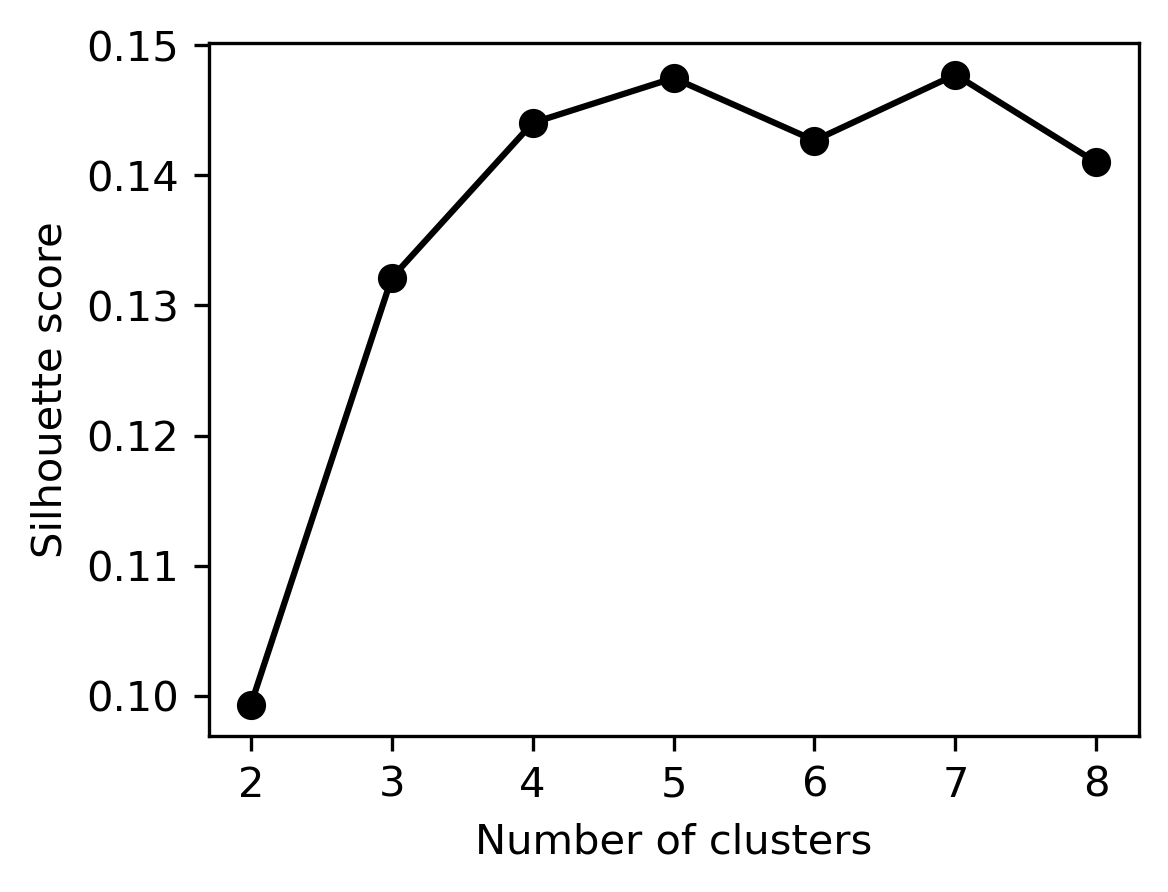

In [16]:
from sklearn.metrics import silhouette_score

sil = []
Ks = range(2, 9)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels_k = km.fit_predict(X_std_grid)
    sil.append(silhouette_score(X_std_grid, labels_k))

plt.figure(figsize=(4,3), dpi=300)
plt.plot(Ks, sil, marker='o',c='k')
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
# plt.title("Silhouette analysis")
plt.show()


In [17]:


# -----------------------------
# # 3) KMeans clustering (3 clusters)
# -----------------------------
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=50)
labels = kmeans.fit_predict(X_std_grid)  # (Npoints,)
np.save('Med_JJA_FWI_cluster',labels)

c:\Users\yinglint\AppData\Local\anaconda3\envs\myenv39\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [18]:
labels = np.load('Med_JJA_FWI_cluster.npy',allow_pickle='True')
n_clusters = 3

In [19]:

cluster_colors = {
    0: "#1f77b4",  # blue
    1: "#2ca02c",  # green
    2: "#ff7f0e",  # orange
}

cluster_names = {
    0: "C-Med",  # blue
    1: "E-Med",  # orange
    2: "W-Med",  # green
}

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches


cmap_clusters = ListedColormap(
    [cluster_colors[k] for k in range(n_clusters)]
)

norm_clusters = BoundaryNorm(
    boundaries=np.arange(-0.5, n_clusters + 0.5, 1),
    ncolors=n_clusters
)


cluster_names_new = {
    0: "CMed",  # blue
    1: "EMed",  # orange
    2: "WMed",  # green
}

Cluster 0: n=141, mean(lat,lon)=(41.82, 18.00)
Cluster 1: n=94, mean(lat,lon)=(39.24, 34.28)
Cluster 2: n=112, mean(lat,lon)=(41.17, -0.77)


(-1838519.5178124253, 4596298.794531064, 2673797.9667449812, 5939113.229856349)

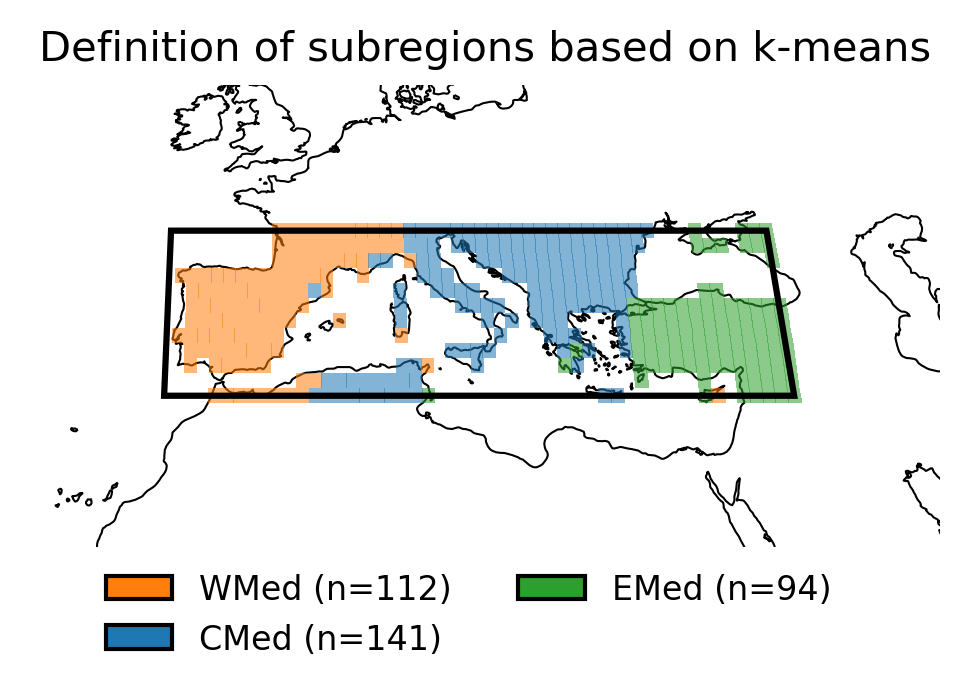

In [20]:

# -----------------------------
# 4) Return lat/lon for each cluster
# -----------------------------
clusters = {}
for k in range(n_clusters):
    clusters[k] = {
        "lat": lat_region[labels == k],
        "lon": lon_region[labels == k],
        "npoints": int(np.sum(labels == k))
    }

# Print summary + approximate "centroid location" (mean lat/lon)
for k in range(n_clusters):
    clat = np.mean(clusters[k]["lat"])
    clon = np.mean(clusters[k]["lon"])
    print(f"Cluster {k}: n={clusters[k]['npoints']}, mean(lat,lon)=({clat:.2f}, {clon:.2f})")

# -----------------------------
# 5) Build a 2D cluster map for plotting (NaN outside region)
# -----------------------------
cluster_map = np.full(LAT_era5.shape, np.nan, dtype=float)

# Put labels back into the region points that survived valid_pt filtering
tmp = np.full(lat_region.shape, np.nan, dtype=float)
tmp[:] = labels
cluster_map[region_mask] = np.nan
cluster_map[region_mask][valid_pt] = tmp

# NOTE: The line above may not assign as expected because boolean indexing makes a copy.
# Use indices to be safe:
idx = np.where(region_mask)
cluster_map[idx] = np.nan
cluster_map[idx[0][valid_pt], idx[1][valid_pt]] = labels

# -----------------------------
# 6) Plot: mean FWI + rectangle + cluster overlay
# -----------------------------
fig, ax = plt.subplots(figsize=(4,2), subplot_kw={'projection': ccrs.Robinson()},dpi=300)
fig.patch.set_alpha(0)

# Rectangle box
rect = mpatches.Rectangle(
    (lon_min, lat_min),
    lon_max - lon_min,
    lat_max - lat_min,
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)
ax.add_patch(rect)


pm = ax.pcolormesh(
    LON_era5_180, LAT_era5, cluster_map,
    transform=ccrs.PlateCarree(),
    shading='auto',
    alpha=0.55,
    zorder=9,
    cmap = cmap_clusters,
    norm = norm_clusters
)

ax.coastlines(linewidth=0.5)
# co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=30)
# co.set_label('Mean FWI')

ax.set_extent([lon_min-10, lon_max+10, lat_min-10, lat_max+10], crs=ccrs.PlateCarree())
ax.set_title('Definition of subregions based on k-means',fontsize=10)
# ax.axis('off')


# -----------------------------
# clusters dict is your "return":
# clusters[0]["lat"], clusters[0]["lon"], etc.
# -----------------------------


legend_handles = [
    mpatches.Patch(
        facecolor=cluster_colors[k],
        edgecolor='black',
        label=f"{cluster_names_new[k]} (n={clusters[k]['npoints']})"
    )
    for k in [2,0,1]
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=False,
    fontsize=8,
    bbox_to_anchor=(0.05,-0.3),
    ncol=2
)
ax.axis('off')



### SM/ aridity

In [5]:

NCData = Dataset(r'C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/data/ERA5_globe_1950_2025/land_sea_mask_2023_01_01_1x1.nc')
land_mask = np.squeeze(NCData.variables['var172'][:])
lon_era5= NCData.variables['lon'][:][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
print(NCData.variables['lon'][:][:][:10])
print(NCData.variables['lat'][:][:][:10])
NCData.close()

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[90. 89. 88. 87. 86. 85. 84. 83. 82. 81.]


In [6]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/data/ERA5_globe_1950_2025/ERA5_1950_2025_swvl1_land_1.x1._3daymean.nc') #current shape = (365, 180,360)

SM = np.squeeze(NCData.variables['var39'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

NCData.close()

In [26]:
lon_min, lon_max = -10, 40
lat_min, lat_max = 35, 46
lon1_min_clusters = [10,28,-10]
lon1_max_clusters = [28,40,10]
lat1_min_clusters = [35,35,35]
lat1_max_clusters = [46,46,46]

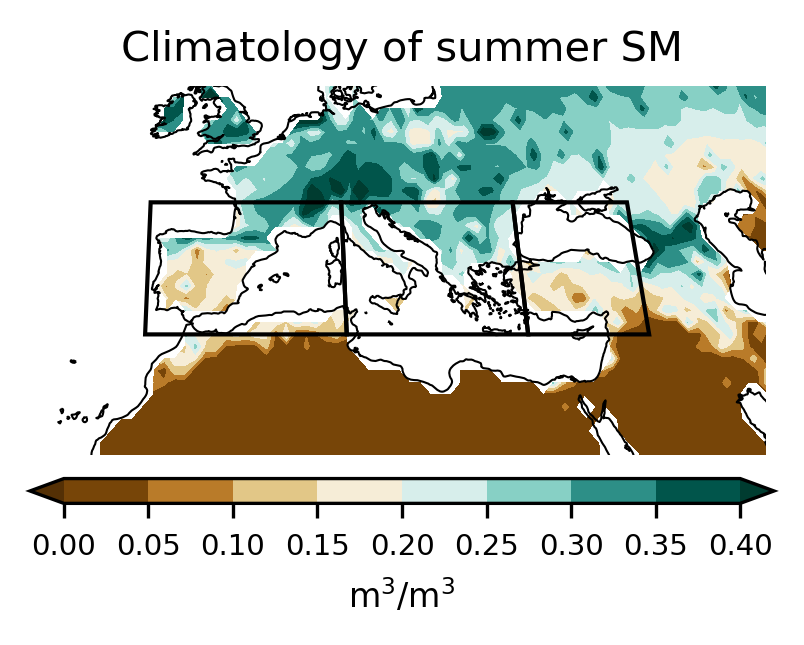

In [139]:



temp_JJA = np.nanmean(SM[np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,range(1979,2026))],axis=0)
temp_JJA[land_mask<0.3]=np.nan

temp_cyclic, lon_cyclic = add_cyclic_point(temp_JJA, coord=LON_era5[0, :])
lon2d, lat2d = np.meshgrid(lon_cyclic, LAT_era5[:, 0])


# 绘图
fig, ax = plt.subplots(figsize=(4,2), subplot_kw={'projection': ccrs.Robinson()},dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(0,0.45,0.05)
contour = ax.contourf(
    lon2d, lat2d, temp_cyclic,
    levels=levels,
    transform=ccrs.PlateCarree(),  
    cmap='BrBG',
    extend='both'
)

rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)

rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)

for k in [0,1,2]:
    lon_min1 = lon1_min_clusters[k]
    lon_max1 = lon1_max_clusters[k]
    lat_min1 = lat1_min_clusters[k]
    lat_max1 = lat1_max_clusters[k]
    rect = mpatches.Rectangle(
        (lon_min1, lat_min1),                 # lower-left corner
        lon_max1 - lon_min1,                  # width
        lat_max1 - lat_min1,                  # height
        linewidth=1,
        edgecolor='black',
        facecolor='none',
        transform=ccrs.PlateCarree(),
        zorder=10
    )
    ax.add_patch(rect)


ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8, aspect=30)
co.ax.tick_params(labelsize=7)
co.set_label(r'm$^{3}$/m$^{3}$',fontsize=8)
ax.set_extent([lon_min-10, lon_max+10, lat_min-10, lat_max+10], crs=ccrs.PlateCarree())
ax.set_title(r'Climatology of summer SM',fontsize=10)
ax.axis('off')
plt.show()

c:\Users\yinglint\AppData\Local\anaconda3\envs\myenv39\lib\site-packages\numpy\lib\nanfunctions.py:1746: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


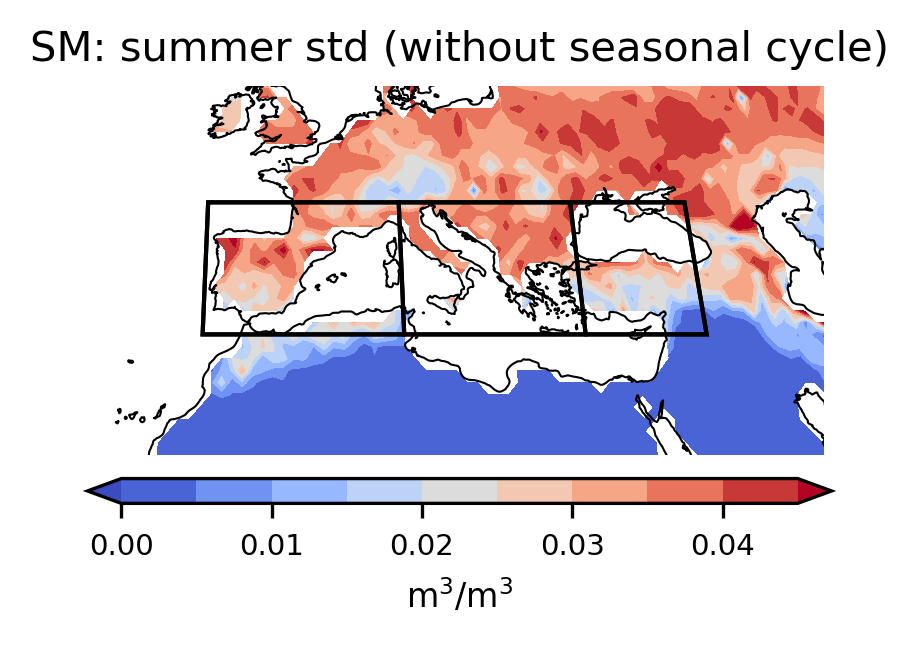

In [90]:
import cartopy.crs as ccrs
import matplotlib.patches as mpatches

temp_JJA = np.nanstd(SM_de[np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,range(1979,2026))],axis=0)
temp_JJA[land_mask<0.3]=np.nan
temp_cyclic, lon_cyclic = add_cyclic_point(temp_JJA, coord=LON_era5[0, :])
lon2d, lat2d = np.meshgrid(lon_cyclic, LAT_era5[:, 0])


# 绘图
fig, ax = plt.subplots(figsize=(4,2), subplot_kw={'projection': ccrs.Robinson()},dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(0,0.05,0.005)
contour = ax.contourf(
    lon2d, lat2d, temp_cyclic,
    levels=levels,
    transform=ccrs.PlateCarree(),  
    cmap='coolwarm',
    extend='both'
)

rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)
ax.add_patch(rect)
for k in [0,1,2]:
    lon_min1 = lon1_min_clusters[k]
    lon_max1 = lon1_max_clusters[k]
    lat_min1 = lat1_min_clusters[k]
    lat_max1 = lat1_max_clusters[k]
    rect = mpatches.Rectangle(
        (lon_min1, lat_min1),                 # lower-left corner
        lon_max1 - lon_min1,                  # width
        lat_max1 - lat_min1,                  # height
        linewidth=1,
        edgecolor='black',
        facecolor='none',
        transform=ccrs.PlateCarree(),
        zorder=10
    )
    ax.add_patch(rect)


ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8, aspect=30)
co.ax.tick_params(labelsize=7)
co.set_ticks(levels[::2])
co.set_label(r'm$^{3}$/m$^{3}$',fontsize=8)
ax.set_extent([lon_min-10, lon_max+10, lat_min-10, lat_max+10], crs=ccrs.PlateCarree())
ax.set_title(r'SM: summer std (without seasonal cycle)',fontsize=10)
ax.axis('off')
plt.show()

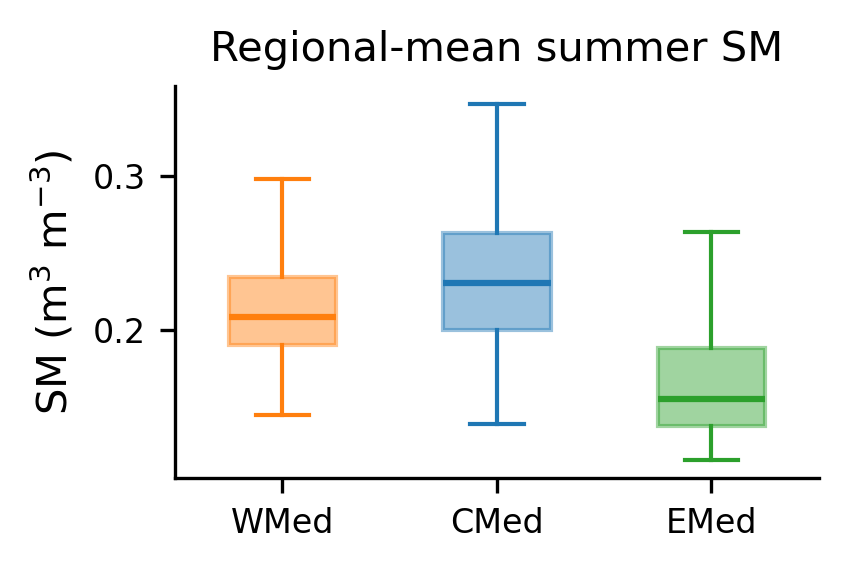

In [140]:
cluster_name_all = ['W-Med_','C-Med_','E-Med_']
cluster_colors = ["#ff7f0e","#1f77b4","#2ca02c"]

fig, ax = plt.subplots(figsize=(3,2), dpi=300)

for i, cluster_c, cluster_name in zip(range(3), cluster_colors, cluster_name_all):
    SM_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name+'SM_1950_2025_3d.npy', allow_pickle=True)
    temp = SM_region[np.in1d(mon_era5_all,[6,7,8]) & np.in1d(year_era5_all,np.arange(1979,2026))]
    # temp = temp[temp < np.nanpercentile(temp,50)]
    ax.boxplot(temp, positions=[i], widths=0.5, patch_artist=True, showfliers=False, boxprops=dict(facecolor=cluster_c, edgecolor=cluster_c, alpha=0.45), medianprops=dict(color=cluster_c, linewidth=1.5), whiskerprops=dict(color=cluster_c), capprops=dict(color=cluster_c))

ax.set_xticks([0,1,2])
ax.set_xticklabels(['WMed','CMed','EMed'])
ax.set_ylabel(r'SM (m$^3$ m$^{-3}$)')
ax.spines[['top','right']].set_visible(False)
ax.tick_params(labelsize=8)
ax.set_title(r'Regional-mean summer SM',fontsize=10)
plt.tight_layout()
plt.show()

# land mask, time and spatial information, aridity index

In [21]:
def remove_seasonal(var,yearN,stepN):
    var_detrend = np.zeros_like(var)
    for i_box in range(stepN):
        temp = np.array([var[stepN*i_year+i_box] for i_year in range(yearN)])
        temp = temp - np.array(len(temp)*[np.nanmean(temp,axis=0)])
        temp = signal.detrend(temp,axis=0)
        for i_year in range(yearN):
            var_detrend[stepN*i_year+i_box]  = temp[i_year]
    return var_detrend 

In [22]:
def remove_seasonal_new(var,yearN,stepN,mon_temp):
    var_detrend = np.zeros_like(var)
    for i_box in range(stepN):
        temp = np.array([var[stepN*i_year+i_box] for i_year in range(yearN)]) 
        temp = temp - np.array(len(temp)*[np.nanmean(var[np.in1d(mon_temp,mon_temp[i_box])],axis=0)])
        temp = signal.detrend(temp,axis=0)
        for i_year in range(yearN):
            var_detrend[stepN*i_year+i_box]  = temp[i_year]
    return var_detrend 

In [ ]:
# def remove_seasonal_normalized(var,yearN,stepN):
#     var_detrend = np.zeros_like(var)
#     for i_box in range(stepN):
#         temp = np.array([var[stepN*i_year+i_box] for i_year in range(yearN)])
#         temp = (temp - np.array(len(temp)*[np.nanmean(temp,axis=0)]))/np.array(len(temp)*[np.nanstd(temp,axis=0)])
#         temp = signal.detrend(temp,axis=0)
#         for i_year in range(yearN):
#             var_detrend[stepN*i_year+i_box]  = temp[i_year]
#     return var_detrend 

# Time info and regional mean

In [23]:

year_era5_all = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/time_year_1950_2025_3d.npy', allow_pickle='True')
mon_era5_all = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/time_mon_1950_2025_3d.npy', allow_pickle='True')
day_era5_all = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/time_day_1950_2025_3d.npy', allow_pickle='True')


In [24]:
stepN = len(year_era5_all[year_era5_all==1979])
yearN = 2025 - 1979 +1

# PCMCI

In [30]:
import numpy as np

def drop_edge_by_sign(graph, Links, q_matrix, var_names,
                      src_name, tgt_name,
                      drop_if_positive=False, drop_if_negative=False,
                      tau_min=0, tau_max=2):
    """
    删除 src->tgt 在指定 tau 范围内、满足符号条件的边。
    drop_if_positive=True: 若 Links>0 则删除
    drop_if_negative=True: 若 Links<0 则删除
    """
    g = graph.copy()
    L = Links.copy()
    q = q_matrix.copy()

    i = var_names.index(src_name)
    j = var_names.index(tgt_name)

    for tau in range(tau_min, tau_max + 1):

        val = L[i, j, tau]
        if not np.isfinite(val):
            continue

        to_drop = (drop_if_positive and (val > 0)) or (drop_if_negative and (val < 0))
        if not to_drop:
            continue

        # 1) 从 graph 里移除边（这是决定图上是否显示 lag 的关键）
        if g.dtype == bool:
            g[i, j, tau] = False
        else:
            # string graph: 空字符串表示“无边”
            g[i, j, tau] = ""

        # 2) 同步清空强度与显著性，避免绘图残留
        L[i, j, tau] = 0.0
        q[i, j, tau] = 1.0  # 不显著

    return g, L, q


In [31]:
cluster_name_all = ['W-Med_','C-Med_','E-Med_']
cluster_colors = [
        "#ff7f0e",  # orange
     "#1f77b4",  # blue

    "#2ca02c",  # green
]

## evolution

In [32]:
cluster_name_all

['W-Med_', 'C-Med_', 'E-Med_']

In [28]:
for cluster_c,cluster_name in zip(cluster_colors ,cluster_name_all):
    FWI_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'FWI_1950_2025_3d.npy', allow_pickle='True')
    SM_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'SM_1950_2025_3d.npy', allow_pickle='True')
    Z500_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'Z500_pattern_index_1979_2025_3d_95_JJA.npy', allow_pickle='True')
    SNAO = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/summerNAO_index_1950_2025_3d_allyear.npy', allow_pickle='True')
    Etesians_index = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/Etesians_index_1950_2025_3d_allyear.npy', allow_pickle='True')
    print(linregress(Z500_region ,SNAO[np.in1d(mon_era5_all,[6,7,8])&np.in1d(year_era5_all,np.arange(1979,2026))]))

LinregressResult(slope=-0.30553024044870436, intercept=0.022254460026938056, rvalue=-0.23976842001371232, pvalue=1.6954948932836323e-20, stderr=0.03243201719796133, intercept_stderr=0.012873448104256559)
LinregressResult(slope=-0.7011372162211111, intercept=0.03370440779373003, rvalue=-0.6568633843629934, pvalue=1.2187938593394044e-180, stderr=0.021099557709670706, intercept_stderr=0.010004825105910085)
LinregressResult(slope=-0.9446738638999462, intercept=0.023909971051217793, rvalue=-0.4134139524118538, pvalue=3.054337282947408e-61, stderr=0.05454636635972336, intercept_stderr=0.012073451076862706)


In [29]:
for cluster_c,cluster_name in zip(cluster_colors ,cluster_name_all):
    FWI_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'FWI_1950_2025_3d.npy', allow_pickle='True')
    SM_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'SM_1950_2025_3d.npy', allow_pickle='True')
    Z500_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'Z500_pattern_index_1979_2025_3d_95_JJA.npy', allow_pickle='True')
    SNAO = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/summerNAO_index_1950_2025_3d_allyear.npy', allow_pickle='True')
    Etesians_index = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/Etesians_index_1950_2025_3d_allyear.npy', allow_pickle='True')
    print(linregress(FWI_region , Etesians_index ))

LinregressResult(slope=0.2733578566654603, intercept=0.565224563370746, rvalue=0.40032188317186096, pvalue=0.0, stderr=0.006525939124480746, intercept_stderr=0.04973098176024797)
LinregressResult(slope=0.40016052791388224, intercept=0.23961673641971215, rvalue=0.48824109122545356, pvalue=0.0, stderr=0.007459625443738846, intercept_stderr=0.04751059986588869)
LinregressResult(slope=0.1664559501811411, intercept=0.4937828014087817, rvalue=0.40033810540944254, pvalue=0.0, stderr=0.003973651947962723, intercept_stderr=0.0509151006899679)


C:\Users\yinglint\AppData\Local\Temp\ipykernel_2184\1503581541.py:51: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(5, 3))


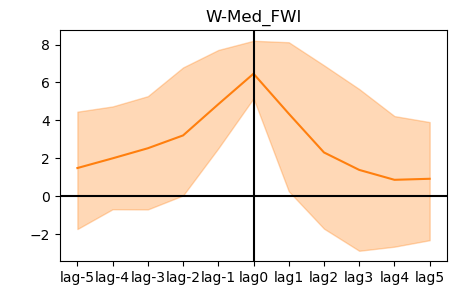

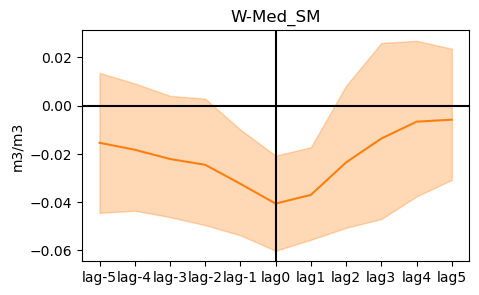

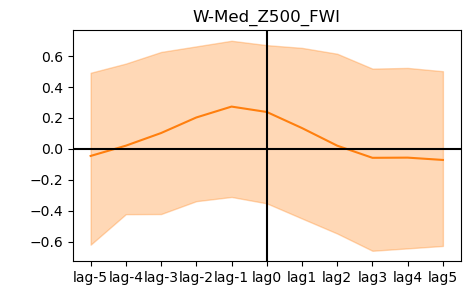

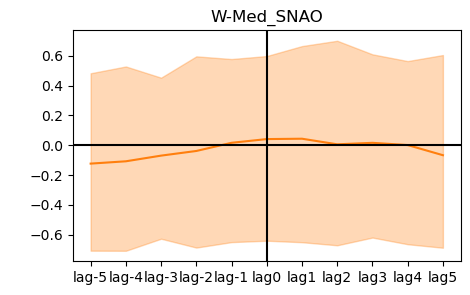

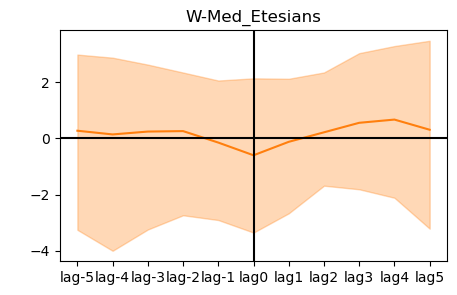

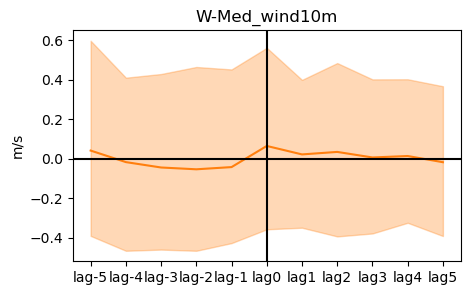

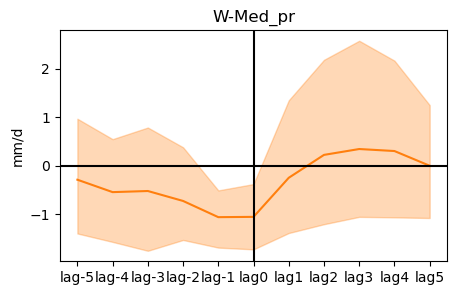

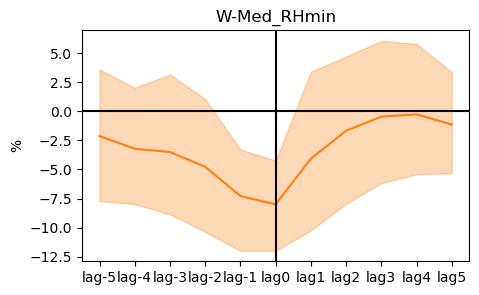

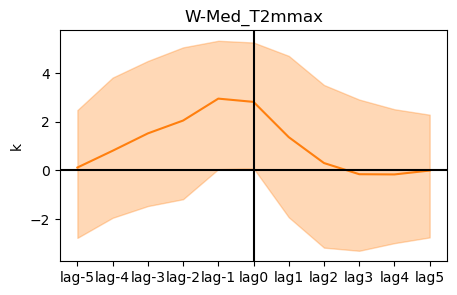

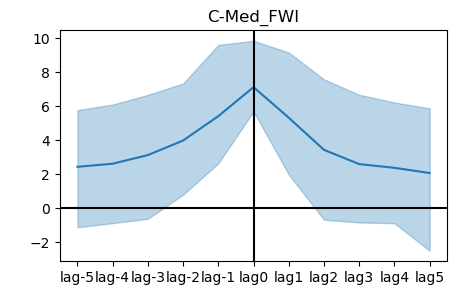

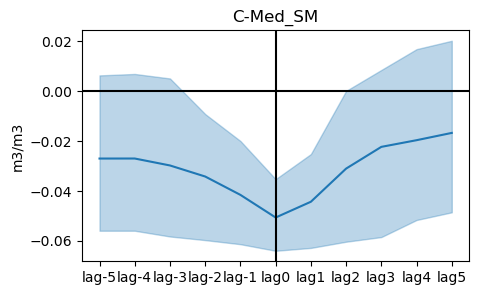

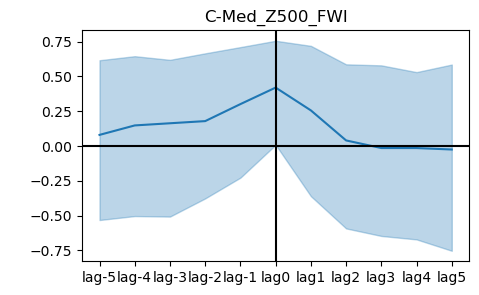

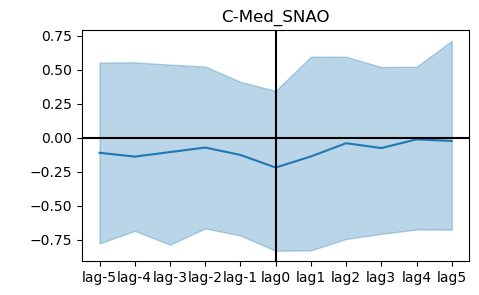

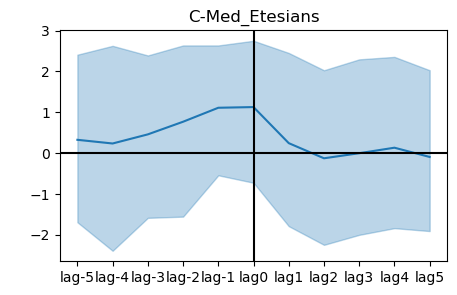

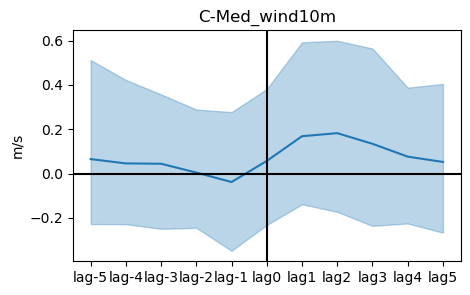

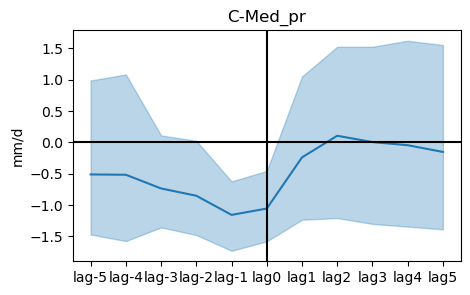

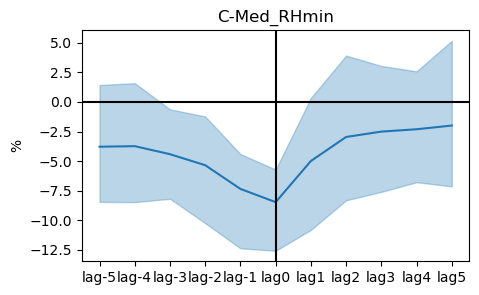

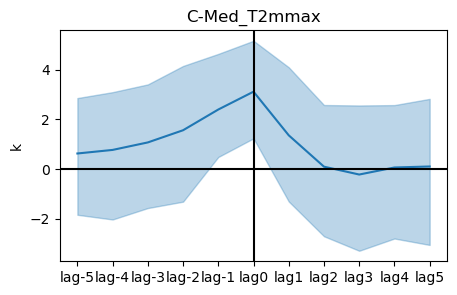

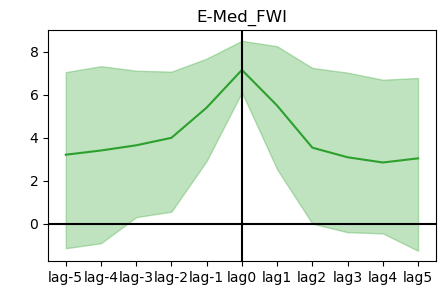

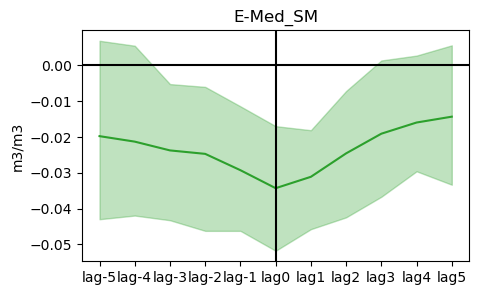

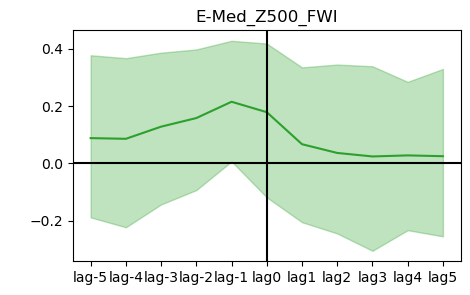

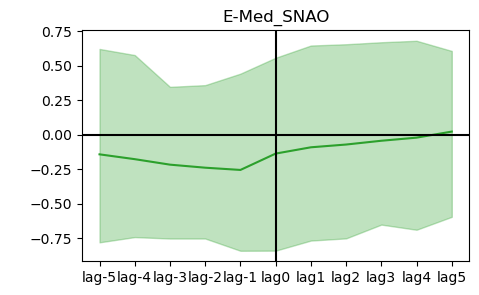

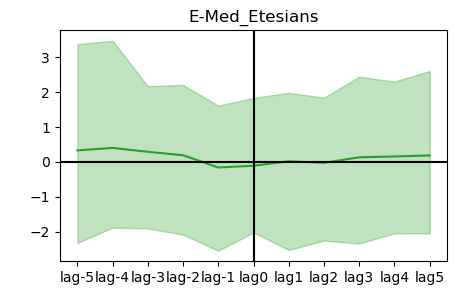

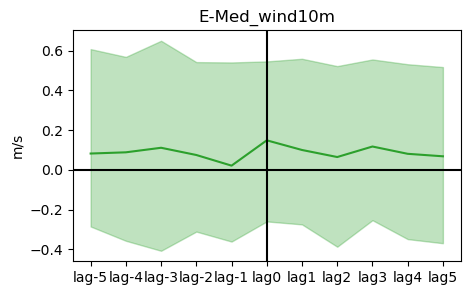

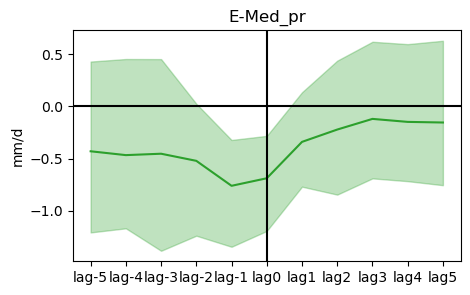

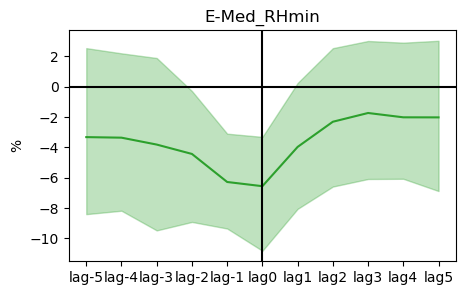

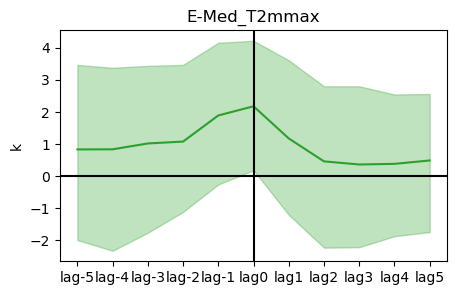

In [13]:
for cluster_c,cluster_name in zip(cluster_colors ,cluster_name_all):
    FWI_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'FWI_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    SM_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'SM_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    Z500_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'Z500_pattern_index_1979_2025_3d_95.npy', allow_pickle='True')
    SNAO = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/summerNAO_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]
    Etesians_index = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/Etesians_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]
    

    wind10m_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'wind10_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    pr_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'pr_1950_2025_3d.npy', allow_pickle='True')[121*29:]*24*1000
    RHmin_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'RHmin_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    T2mmax_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'T2mmax_1950_2025_3d.npy', allow_pickle='True')[121*29:]

    FWI_region_de = copy.deepcopy(remove_seasonal(FWI_region,yearN,stepN))
    SM_region_de = copy.deepcopy(remove_seasonal(SM_region,yearN,stepN))
    Z500_region_de = copy.deepcopy(remove_seasonal(Z500_region,yearN,stepN))
    SNAO_de = copy.deepcopy(remove_seasonal(SNAO,yearN,stepN))
    Etesians_de = copy.deepcopy(remove_seasonal(Etesians_index,yearN,stepN))

    wind10m_region_de = copy.deepcopy(remove_seasonal(wind10m_region,yearN,stepN))
    pr_region_de = copy.deepcopy(remove_seasonal(pr_region,yearN,stepN))
    RHmin_region_de = copy.deepcopy(remove_seasonal(RHmin_region,yearN,stepN))
    T2mmax_region_de = copy.deepcopy(remove_seasonal(T2mmax_region,yearN,stepN))   

    thr = np.nanpercentile(FWI_region_de[np.in1d(mon_era5_all[121*29:],[6,7,8])],95)
    extreme_index = np.where(np.in1d(mon_era5_all[121*29:],[6,7,8])&(FWI_region_de>thr))[0]

    extreme_FWI = []
    extreme_SM = []
    extreme_Z500 = []
    extreme_SNAO = []
    extreme_Etesians = []

    extreme_wind10m = []
    extreme_pr = []
    extreme_RHmin = []
    extreme_T2mmax = []
    
    for i in extreme_index:
        extreme_FWI.append(FWI_region_de[i-5:i+6])
        extreme_SM.append(SM_region_de[i-5:i+6])
        extreme_Z500.append(Z500_region_de[i-5:i+6])
        extreme_SNAO.append(SNAO_de [i-5:i+6])
        extreme_Etesians.append(Etesians_de [i-5:i+6])
        extreme_wind10m.append(wind10m_region_de[i-5:i+6])
        extreme_pr.append(pr_region_de[i-5:i+6])
        extreme_RHmin.append(RHmin_region_de[i-5:i+6])
        extreme_T2mmax.append(T2mmax_region_de[i-5:i+6])

    for i_v,i_vname,i_vunit in zip([extreme_FWI, extreme_SM, extreme_Z500,extreme_SNAO ,extreme_Etesians, extreme_wind10m, extreme_pr, extreme_RHmin,extreme_T2mmax],['FWI', 'SM', 'Z500_FWI', 'SNAO','Etesians','wind10m', 'pr', 'RHmin','T2mmax'],[' ','m3/m3',' ',' ',' ','m/s', 'mm/d','%','k']):
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.plot(np.nanmean(i_v ,axis=0),color=cluster_c)
        ax.fill_between(np.arange(11),np.nanpercentile(i_v ,10,axis=0),np.nanpercentile(i_v,90 ,axis=0),alpha=0.3,color=cluster_c)
        ax.set_xticks(np.arange(11))
        ax.set_xticklabels([f'lag{ii}' for ii in np.arange(-5,6)])
        ax.axvline(5,c='k')
        ax.axhline(0,c='k')
        plt.title(cluster_name+i_vname)
        plt.ylabel(i_vunit )


## BASIC

In [33]:
cluster_name_all

['W-Med_', 'C-Med_', 'E-Med_']

In [34]:
var_names_all =  [[r'FWI$_{W}$',r'SM$_{W}$', r'Z500$_{W}$','SNAO','Etesians'],[r'FWI$_{C}$',r'SM$_{C}$', r'Z500$_{C}$','SNAO','Etesians'],[r'FWI$_{E}$',r'SM$_{E}$', r'Z500$_{E}$','SNAO','Etesians']]
for cluster_name, plot_names in zip (cluster_name_all,var_names_all ):
    FWI_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'FWI_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    SM_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'SM_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    Z500_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'Z500_pattern_index_1979_2025_3d_95.npy', allow_pickle='True')
    SNAO = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/summerNAO_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]
    wind10m_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'wind10_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    Etesians_index = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/Etesians_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]

    FWI_region_de = copy.deepcopy(remove_seasonal(FWI_region,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]
    SM_region_de = copy.deepcopy(remove_seasonal(SM_region,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]
    Z500_region_de = copy.deepcopy(remove_seasonal(Z500_region,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]
    wind10m_region_de = copy.deepcopy(remove_seasonal(wind10m_region,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]
    SNAO_de = copy.deepcopy(remove_seasonal(SNAO,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]
    Etesians_de = copy.deepcopy(remove_seasonal(Etesians_index,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]

    # print(linregress(FWI_region_de[1:]/np.std(FWI_region_de),SM_region_de[:-1]/np.std(SM_region_de)))
    print(linregress((FWI_region-np.nanmean(FWI_region))[np.in1d(mon_era5_all[121*29:],[6,7,8])][1:]/np.std(FWI_region),SM_region_de[:-1]/np.std(SM_region_de)))

LinregressResult(slope=-0.4989598254272464, intercept=0.6355203606429536, rvalue=-0.409743216189803, pvalue=4.766425241968258e-60, stderr=0.029131450145687018, intercept_stderr=0.0441781075529751)
LinregressResult(slope=-0.5947117522035766, intercept=0.7517896105030072, rvalue=-0.5380308570323826, pvalue=4.8558476671239784e-110, stderr=0.024434651084500186, intercept_stderr=0.03799122419152869)
LinregressResult(slope=-0.5591282146193649, intercept=0.6859796204474577, rvalue=-0.3711224586151233, pvalue=9.145175607896209e-49, stderr=0.03668876839310929, intercept_stderr=0.05115227588009436)


In [35]:
var_names_all =  [[r'FWI$_{W}$',r'SM$_{W}$', r'Z500$_{W}$','SNAO','Etesians'],[r'FWI$_{C}$',r'SM$_{C}$', r'Z500$_{C}$','SNAO','Etesians'],[r'FWI$_{E}$',r'SM$_{E}$', r'Z500$_{E}$','SNAO','Etesians']]
for cluster_name, plot_names in zip (cluster_name_all,var_names_all ):
    FWI_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'FWI_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    SM_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'SM_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    Z500_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'Z500_pattern_index_1979_2025_3d_95.npy', allow_pickle='True')
    SNAO = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/summerNAO_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]
    wind10m_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'wind10_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    Etesians_index = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/Etesians_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]

    FWI_region_de = copy.deepcopy(remove_seasonal(FWI_region,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]
    SM_region_de = copy.deepcopy(remove_seasonal(SM_region,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]
    Z500_region_de = copy.deepcopy(remove_seasonal(Z500_region,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]
    wind10m_region_de = copy.deepcopy(remove_seasonal(wind10m_region,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]
    SNAO_de = copy.deepcopy(remove_seasonal(SNAO,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]
    Etesians_de = copy.deepcopy(remove_seasonal(Etesians_index,yearN,stepN))[np.in1d(mon_era5_all[121*29:],[6,7,8])]

    # print(linregress(FWI_region_de[1:]/np.std(FWI_region_de),SM_region_de[:-1]/np.std(SM_region_de)))
    print(linregress((FWI_region-np.nanmean(FWI_region))[np.in1d(mon_era5_all[121*29:],[6,7,8])]/np.std(FWI_region),SM_region_de/np.std(SM_region_de)))

LinregressResult(slope=-0.682271054004874, intercept=0.8690991053087563, rvalue=-0.5607985017032376, pvalue=1.856647584575692e-121, stderr=0.02640729586385426, intercept_stderr=0.04003354125256359)
LinregressResult(slope=-0.7444824762410577, intercept=0.9408568233825544, rvalue=-0.6736790836442949, pvalue=2.4536553956373823e-193, stderr=0.021410581847897944, intercept_stderr=0.03327922526736998)
LinregressResult(slope=-0.7778416148476873, intercept=0.9529092240449623, rvalue=-0.5169842314773334, pvalue=2.2476122925272834e-100, stderr=0.03376397488296607, intercept_stderr=0.04705853112310199)


### p=0.01

In [37]:
np.nanmean(FWI_region)

9.081199


# Initialize conditional independence test

Parameters:
independence test = par_corr
significance = analytic
mask_type = y

##
## Step 1: PC1 algorithm with lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 3
pc_alpha = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable FWI has 5 link(s):
    [pc_alpha = 0.2]
        (FWI -1): max_pval = 0.00000, min_val =  0.616
        (SM -1): max_pval = 0.00002, min_val =  0.113
        (SNAO -1): max_pval = 0.00271, min_val = -0.079
        (Etesians -2): max_pval = 0.03114, min_val =  0.056
        (SM -3): max_pval = 0.19583, min_val = -0.034

    Variable SM has 6 link(s):
    [pc_alpha = 0.2]
        (SM -1): max_pval = 0.00000, min_val =  0.477
        (SM -2): max_pval = 0.00049, min_val =  0.091
        (FWI -1): max_pval = 0.00187, min_val = -0.082
        (SNAO -2): max_pval = 0.01406, min_val =  0.064
        (FWI -2): max_

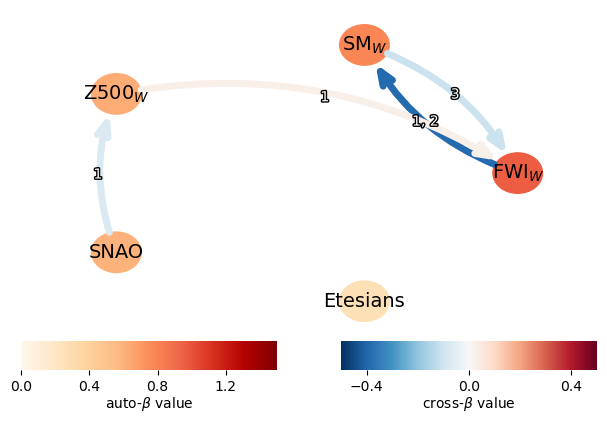

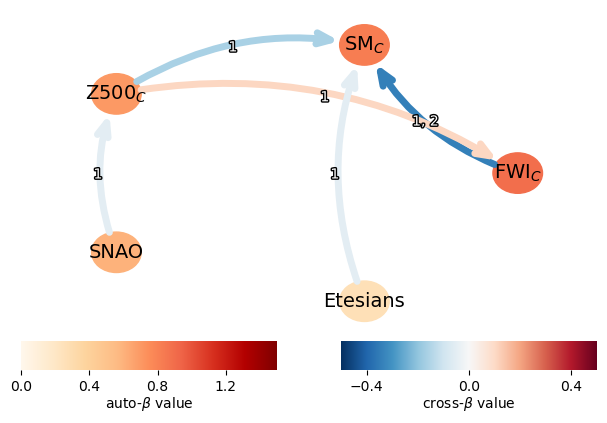

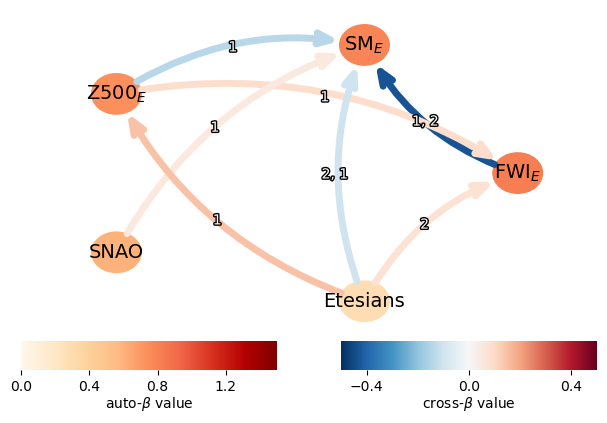

In [ ]:
var_names_all =  [[r'FWI$_{W}$',r'SM$_{W}$', r'Z500$_{W}$','SNAO','Etesians'],[r'FWI$_{C}$',r'SM$_{C}$', r'Z500$_{C}$','SNAO','Etesians'],[r'FWI$_{E}$',r'SM$_{E}$', r'Z500$_{E}$','SNAO','Etesians']]
for cluster_name, plot_names in zip (cluster_name_all,var_names_all ):
    FWI_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'FWI_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    SM_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'SM_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    Z500_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'Z500_pattern_index_1979_2025_3d_95.npy', allow_pickle='True')
    SNAO = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/summerNAO_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]
    wind10m_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'wind10_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    Etesians_index = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/Etesians_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]

    FWI_region_de = copy.deepcopy(remove_seasonal(FWI_region,yearN,stepN))
    SM_region_de = copy.deepcopy(remove_seasonal(SM_region,yearN,stepN))
    Z500_region_de = copy.deepcopy(remove_seasonal(Z500_region,yearN,stepN))
    wind10m_region_de = copy.deepcopy(remove_seasonal(wind10m_region,yearN,stepN))
    SNAO_de = copy.deepcopy(remove_seasonal(SNAO,yearN,stepN))
    Etesians_de = copy.deepcopy(remove_seasonal(Etesians_index,yearN,stepN))

    fulldata =np.vstack( ( (FWI_region_de)/np.std(FWI_region_de),SM_region_de/np.std(SM_region_de),Z500_region_de/np.std(Z500_region_de), SNAO_de/np.std(SNAO_de),Etesians_de/np.std(Etesians_de))).T
    

    # FWI_region_de = copy.deepcopy(remove_seasonal_new(FWI_region,yearN,stepN,mon_era5_all[121*29:]))
    # SM_region_de = copy.deepcopy(remove_seasonal_new(SM_region,yearN,stepN,mon_era5_all[121*29:]))
    # Z500_region_de = copy.deepcopy(remove_seasonal_new(Z500_region,yearN,stepN,mon_era5_all[121*29:]))
    # wind10m_region_de = copy.deepcopy(remove_seasonal_new(wind10m_region,yearN,stepN,mon_era5_all[121*29:]))
    # SNAO_de = copy.deepcopy(remove_seasonal_new(SNAO,yearN,stepN,mon_era5_all[121*29:]))
    # Etesians_de = copy.deepcopy(remove_seasonal_new(Etesians_index,yearN,stepN,mon_era5_all[121*29:]))
    # fulldata =np.vstack( ( (FWI_region_de)/np.std(FWI_region_de),SM_region_de/np.std(SM_region_de),Z500_region_de/np.std(Z500_region_de), SNAO_de/np.std(SNAO_de),Etesians_de/np.std(Etesians_de))).T


    var_names =  ['FWI','SM', 'Z500','SNAO','Etesians']

    data = fulldata
    T, N = data.shape

    # create data mask
    data_mask = np.ones(data.shape, dtype='bool')

    for k in np.where((np.in1d(mon_era5_all[121*29:],[6,7,8])))[0]:
    #for k in np.where((np.in1d(mon_era5_all,[6,7,8]))&(np.in1d(year_era5_all,year_select_Compound)))[0]:
    #for k in HW_Index:
        data_mask[k,:] = False # 
    # print(data_mask[30:365,0:2])


    # Initialize dataframe object (needed for tigramite functions)
    #dataframe = pp.DataFrame(data, mask=data_mask)
    dataframe = pp.DataFrame(data, datatime = np.arange(len(data)), var_names=var_names,mask=data_mask)
    parcorr = ParCorr(significance='analytic', 
                    mask_type='y', 
                    verbosity=1)
    pcmci = PCMCI(
        dataframe=dataframe, 
        cond_ind_test=parcorr,
        selected_variables=None,
        verbosity=1)
    #results = pcmci.run_pc_stable(tau_max=6, pc_alpha=0.01)
    tau_min = 1
    tau_max = 3
    results = pcmci.run_pcmci(tau_max=tau_max,tau_min=tau_min, pc_alpha = None)#[0.3, 0.1,0.05 [0.001, 0.01,0.05, 0.1, 0.2])#None)
    # put also tau_min if you need

    alpha_level_v = 0.01
    q_matrix = pcmci.get_corrected_pvalues(p_matrix=results['p_matrix'], tau_max=tau_max, fdr_method='fdr_bh')

    # pcmci.print_significant_links(
    #         p_matrix = q_matrix,
    #         val_matrix = results['val_matrix'],
    #         alpha_level = 0.01)
    graph = pcmci.get_graph_from_pmatrix(p_matrix=q_matrix, alpha_level=0.01, 
                tau_min=tau_min, tau_max=tau_max, selected_links=None)
    results['graph'] = graph

    sig = pcmci.return_significant_links(
                            pq_matrix=q_matrix,
                            val_matrix=results['val_matrix'], 
                            alpha_level=alpha_level_v)

    # Remove some links link_matrix[i, j, tau] is link  i -- tau --> j
    # link_matrix[[1,2,3,4,], :, :] = False

    all_parents = pcmci.return_parents_dict(graph, val_matrix=results['val_matrix'], include_lagzero_parents=False)
    np.save('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name +'all_parents_withSNAO_withEtesians_p001',all_parents )
    
    #link_matrix = sig['link_matrix']
    # link_matrix = graph
    med = LinearMediation(dataframe=dataframe,            

                mask_type = 'y',
                data_transform = None)
    med.fit_model(all_parents = all_parents, tau_max=tau_max)             
    Links = med.get_val_matrix()
    


    # pcmci.print_significant_links(
    #         #p_matrix = results['p_matrix'], 
    #         #q_matrix = q_matrix,
    #         p_matrix = q_matrix,
    #         val_matrix = Links,
    #         alpha_level = alpha_level_v)




    results['graph'] = graph
    tp.plot_graph(
        val_matrix=Links,
        vmax_edges=0.5,
        vmin_edges=-0.5,
        vmax_nodes=1.5,
        node_label_size=14,
        graph= graph,
        var_names=plot_names,
        link_colorbar_label=r'cross-${\beta}$ value',
        node_colorbar_label=r'auto-${\beta}$ value',

    save_name='C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name +'network_withSNAO_withEtesians_p001.jpg' )
 

# changes

## Etesians

(2356,)
slope = -0.000 K/yr (95% CI [-0.007, 0.005])


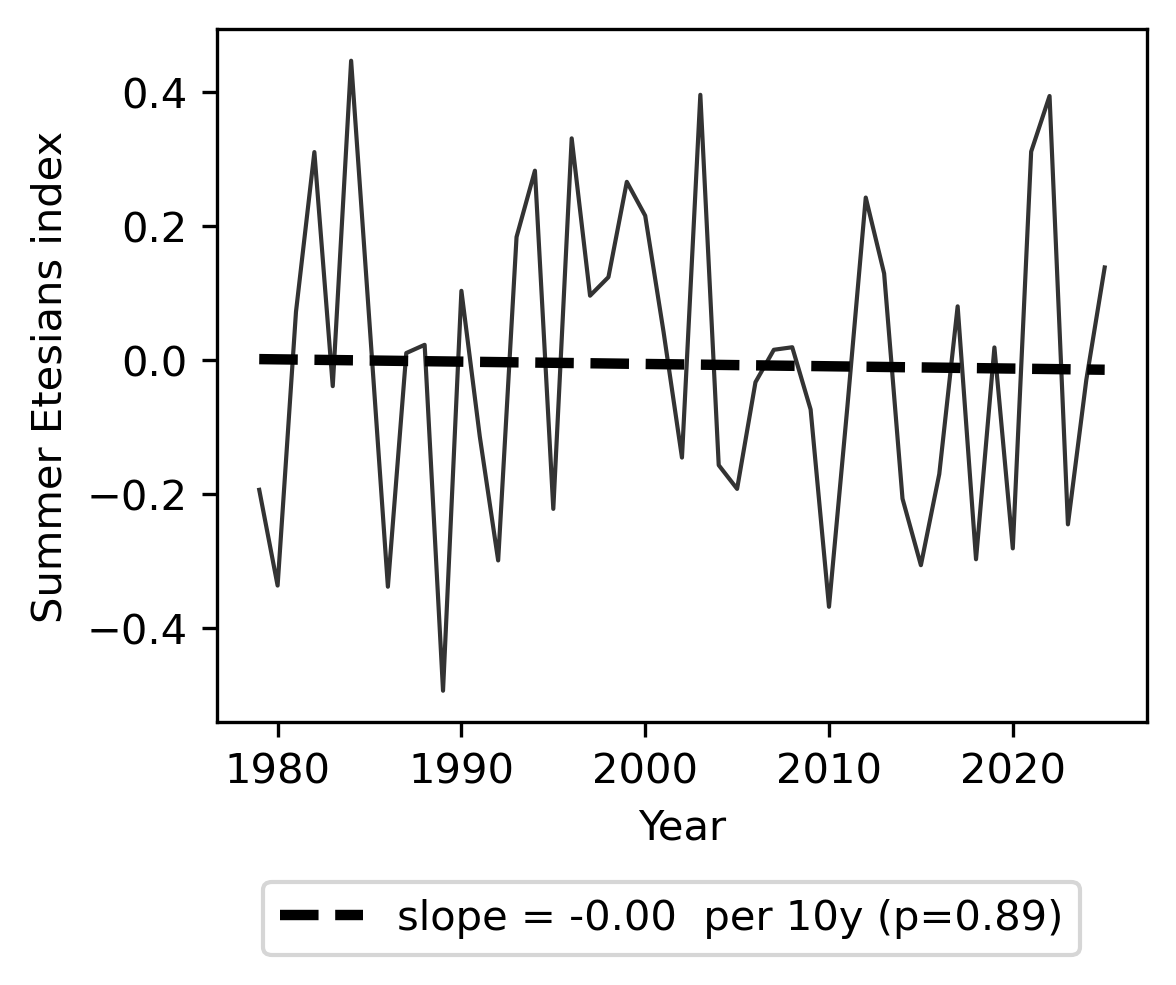

In [68]:


Etesians_index = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/Etesians_index_1950_2025_3d_allyear.npy', allow_pickle='True')

years = np.arange(1979, 2026)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

annual_means = {}


temp = Etesians_index[np.in1d(mon_era5_all,[6,7,8])]
temp = (temp - np.nanmean(temp))/(np.nanstd(temp))
print(temp.shape)
# temp_FWI = FWI_region_clusters[k]
# temp_FWI_thr = np.nanpercentile(temp,90)
# temp_yearmean = np.array([
#     np.nanmean(temp[year_era5_all_JJA == y][temp_FWI[year_era5_all_JJA == y]>temp_FWI_thr] ) for y in years
# ])
temp_yearmean = np.array([
    np.nanmean(temp[year_era5_all_JJA == y] ) for y in years
])
temp_yearmean = temp_yearmean
# annual_means[k] = temp_yearmean

ax.plot(
    years,
    temp_yearmean,
    color='k',
    lw=1.,
    alpha=0.8,
    # label='Summer NAO'
)



y = temp_yearmean
mask = (~np.isnan(y))&(years>=1979)

slope, intercept, lo, hi = theilslopes(
    y[mask], years[mask], 0.95
)



slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
trend = intercept + slope * years[mask]

if p<0.01:
    ax.plot(
    years[mask],
    trend,
    color='k',
    lw=2.5,
    linestyle="--",
    label =  f"slope = {slope*10:.2f}  per 10y (p<0.01)" 
)
else:
    ax.plot(
        years[mask],
        trend,
        color='k',
        lw=2.5,
        linestyle="--",
        label =  f"slope = {slope*10:.2f}  per 10y (p={p:.2f})" 
    )

print(

    f"slope = {slope:.3f} K/yr "
    f"(95% CI [{lo:.3f}, {hi:.3f}])"
)


y = temp_yearmean
mask = ~np.isnan(y)

# lowess_fit = lowess(
#     y[mask],
#     years[mask],
#     frac=0.2,      # ~15-year smoothing
#     return_sorted=False
# )

# ax.plot(
#     years[mask],
#     lowess_fit,
#     color='k',
#     lw=3,
#     alpha=0.35,
#     label = f"LOESS" 
# )
ax.set_xlabel('Year')
ax.set_ylabel('Summer Etesians index')
plt.legend(bbox_to_anchor=(0.95,-0.2))

## SNAO

In [69]:
Summernao_index_all = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/summerNAO_index_1950_2025_3d_allyear.npy',allow_pickle='True')

(2356,)
slope = 0.001 K/yr (95% CI [-0.006, 0.008])


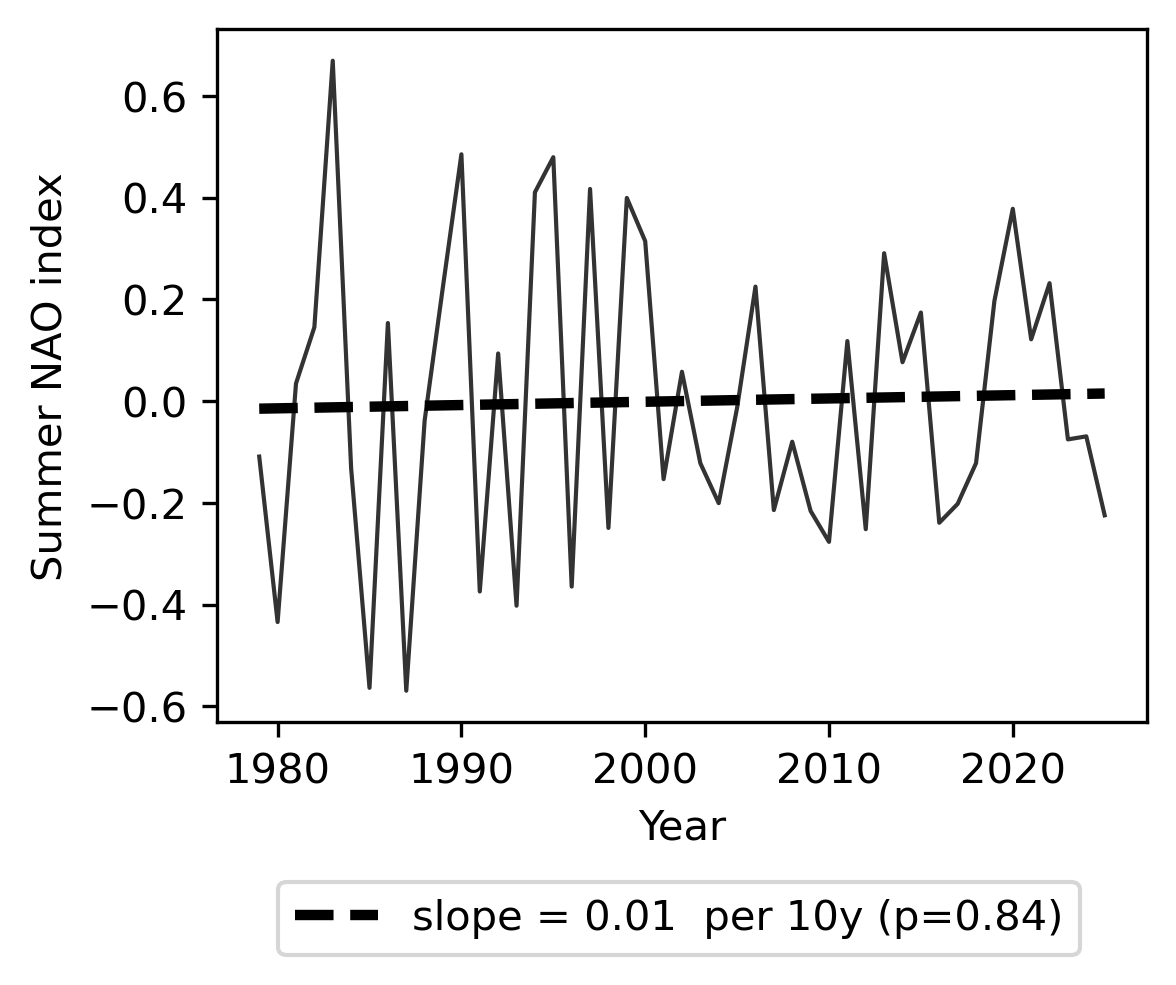

In [70]:

years = np.arange(1979, 2026)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

annual_means = {}


temp = Summernao_index_all[np.in1d(mon_era5_all,[6,7,8])]
print(temp.shape)
temp = (temp - np.nanmean(temp))/(np.nanstd(temp))
# temp_FWI = FWI_region_clusters[k]
# temp_FWI_thr = np.nanpercentile(temp,90)
# temp_yearmean = np.array([
#     np.nanmean(temp[year_era5_all_JJA == y][temp_FWI[year_era5_all_JJA == y]>temp_FWI_thr] ) for y in years
# ])
temp_yearmean = np.array([
    np.nanmean(temp[year_era5_all_JJA == y] ) for y in years
])
temp_yearmean = temp_yearmean-np.nanmean(temp_yearmean)
# annual_means[k] = temp_yearmean

ax.plot(
    years,
    temp_yearmean,
    color='k',
    lw=1.,
    alpha=0.8,
    # label='Summer NAO'
)



y = temp_yearmean
mask = (~np.isnan(y))&(years>=1979)

slope, intercept, lo, hi = theilslopes(
    y[mask], years[mask], 0.95
)



slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
trend = intercept + slope * years[mask]

if p<0.01:
    ax.plot(
    years[mask],
    trend,
    color='k',
    lw=2.5,
    linestyle="--",
    label =  f"slope = {slope*10:.2f}  per 10y (p<0.01)" 
)
else:
    ax.plot(
        years[mask],
        trend,
        color='k',
        lw=2.5,
        linestyle="--",
        label =  f"slope = {slope*10:.2f}  per 10y (p={p:.2f})" 
    )

print(

    f"slope = {slope:.3f} K/yr "
    f"(95% CI [{lo:.3f}, {hi:.3f}])"
)


y = temp_yearmean
mask = ~np.isnan(y)

# lowess_fit = lowess(
#     y[mask],
#     years[mask],
#     frac=0.2,      # ~15-year smoothing
#     return_sorted=False
# )

# ax.plot(
#     years[mask],
#     lowess_fit,
#     color='k',
#     lw=3,
#     alpha=0.35,
#     label = f"LOESS" 
# )
ax.set_xlabel('Year')
ax.set_ylabel('Summer NAO index')
plt.legend(bbox_to_anchor=(0.95,-0.2))

## z500

In [71]:
cluster_sequence = [2,0,1]
time_mask = (np.in1d(year_era5_all,range(1979,2026)))
year_era5_all_JJA1 = year_era5_all[time_mask ]
mon_era5_all_JJA1 = mon_era5_all[time_mask ]
day_era5_all_JJA1 = day_era5_all[time_mask ]

time_mask = (np.in1d(mon_era5_all,[6,7,8]))
year_era5_all_JJA = year_era5_all[time_mask ]
mon_era5_all_JJA = mon_era5_all[time_mask ]
day_era5_all_JJA = day_era5_all[time_mask ]

In [72]:
Z500_region_clusters = []
for k in range(n_clusters):
    Z500_region_clusters.append( np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_names[k]+'_Z500_pattern_index_1979_2025_3d_95.npy',allow_pickle='True'))
n_clusters = 3

(1457,)
(1457,)
(1457,)
W-Med: slope = -0.002 /yr (95% CI [-0.008, 0.005])
C-Med: slope = 0.001 /yr (95% CI [-0.007, 0.008])
E-Med: slope = -0.002 /yr (95% CI [-0.009, 0.006])


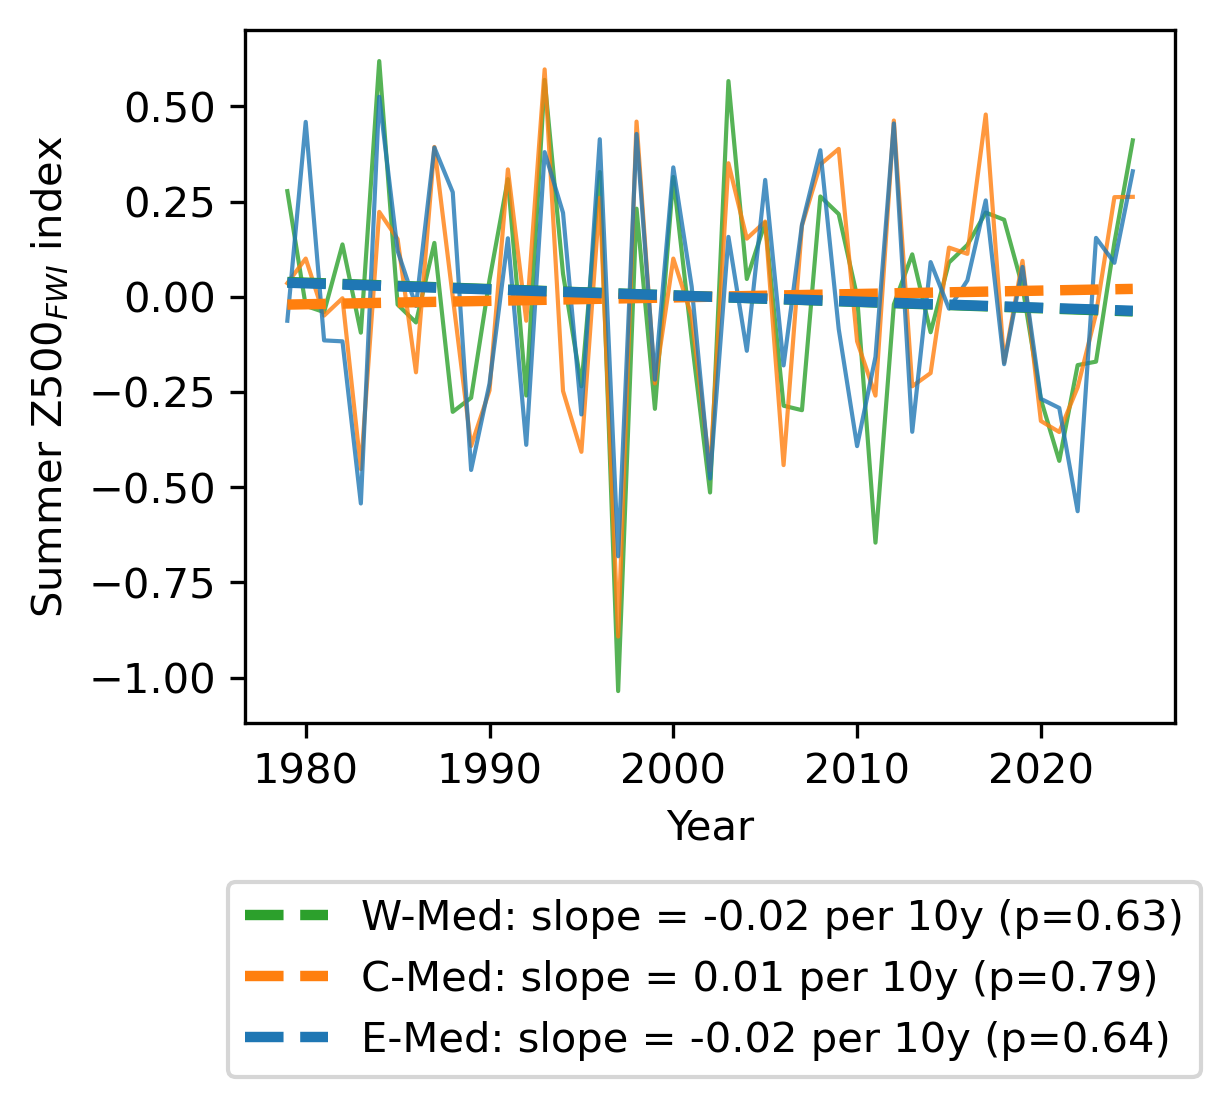

In [73]:




years = np.arange(1979, 2026)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

annual_means = {}

for k in cluster_sequence:
    temp = Z500_region_clusters[k]
    temp = temp[np.in1d(mon_era5_all_JJA1,[6,7,8])]
    print(temp.shape)
    temp = (temp - np.nanmean(temp))/(np.nanstd(temp))
    # temp = temp[np.in1d(mon_era5_all,[6,7,8])]

    # temp_yearmean = np.array([
    #     np.nanmean(temp[year_era5_all_JJA == y][temp_FWI[year_era5_all_JJA == y]>temp_FWI_thr] ) for y in years
    # ])
    temp_yearmean = np.array([
        np.nanmean(temp[year_era5_all_JJA1[np.in1d(mon_era5_all_JJA1,[6,7,8])] == y] ) for y in years
    ])

    temp_yearmean = temp_yearmean 
   
    annual_means[k] = temp_yearmean

    ax.plot(
        years,
        temp_yearmean,
        color=cluster_colors[k],
        lw=1.,
        alpha=0.8,
        # label=cluster_names[k]
    )


for k in cluster_sequence:
    y = annual_means[k]
    mask = (~np.isnan(y))&(years>=1979)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    

    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years[mask]

    if p<0.01:

        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names[k]}: " + f"slope = {slope*10:.2f} per 10y (p<0.01)" 
        )
    else:

        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names[k]}: " + f"slope = {slope*10:.2f} per 10y (p={p:.2f})" 
        )        

    print(
        f"{cluster_names[k]}: "
        f"slope = {slope:.3f} /yr "
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )

# for k in cluster_sequence:
#     y = annual_means[k]
#     mask = ~np.isnan(y)

#     lowess_fit = lowess(
#         y[mask],
#         years[mask],
#         frac=0.2,      # ~15-year smoothing
#         return_sorted=False
#     )

#     ax.plot(
#         years[mask],
#         lowess_fit,
#         color=cluster_colors[k],
#         lw=3,
#         alpha=0.35,
#         label = f"{cluster_names[k]}: " + f"LOESS" 
#     )
ax.set_xlabel('Year')
ax.set_ylabel('Summer Z500$_{FWI}$ index')
plt.legend(bbox_to_anchor=(1.05,-0.2))



## SM

In [74]:
SM_region_clusters= []
for k in range(n_clusters):
    SM_region_clusters.append( np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_names[k]+'_SM_1950_2025_3d.npy',allow_pickle='True'))
n_clusters = 3

(2356,)
(2356,)
(2356,)
W-Med: slope = -0.001 m$^-3$/m$^-3$/yr (95% CI [-0.001, -0.000])
C-Med: slope = -0.001 m$^-3$/m$^-3$/yr (95% CI [-0.001, -0.000])
E-Med: slope = -0.000 m$^-3$/m$^-3$/yr (95% CI [-0.001, 0.000])


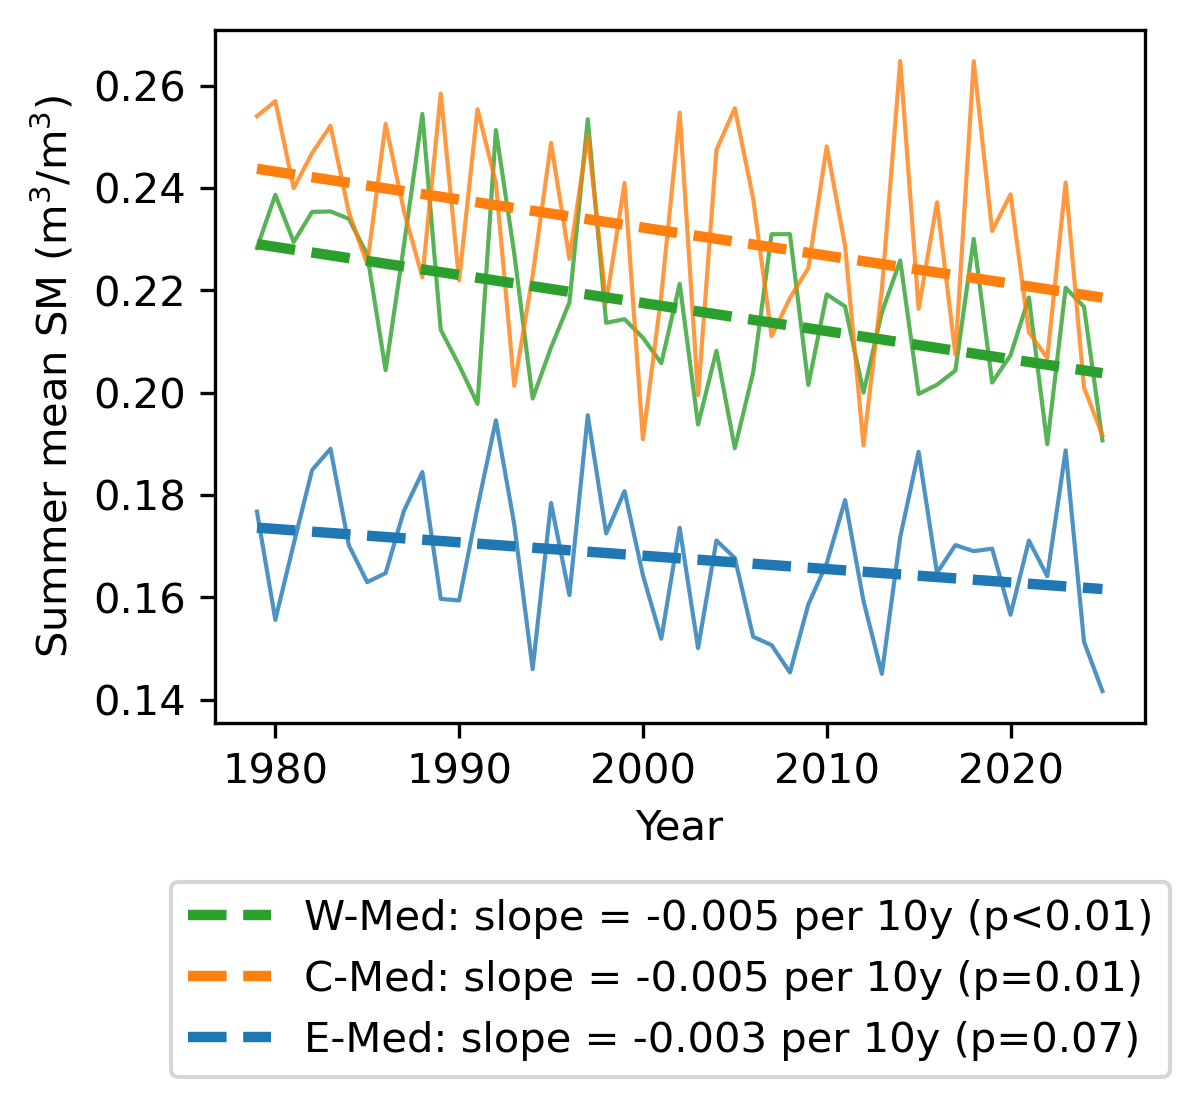

In [75]:




years = np.arange(1979, 2026)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

annual_means = {}

for k in cluster_sequence:
    temp = SM_region_clusters[k]
    temp = temp[np.in1d(mon_era5_all,[6,7,8])]
    print(temp.shape)
    # temp_FWI = FWI_region_clusters[k]

    # temp_yearmean = np.array([
    #     np.nanmean(temp[year_era5_all_JJA == y][temp_FWI[year_era5_all_JJA == y]>temp_FWI_thr] ) for y in years
    # ])
    temp_yearmean = np.array([
        np.nanmean(temp[year_era5_all_JJA == y] ) for y in years
    ])

    temp_yearmean = temp_yearmean 
   
    annual_means[k] = temp_yearmean

    ax.plot(
        years,
        temp_yearmean,
        color=cluster_colors[k],
        lw=1.,
        alpha=0.8,
        # label=cluster_names[k]
    )


for k in cluster_sequence:
    y = annual_means[k]
    mask = (~np.isnan(y))&(years>=1979)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    

    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years[mask]

    if p<0.01:
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names[k]}: " + f"slope = {slope*10:.3f} per 10y (p<0.01)" 
        )
    else:
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names[k]}: " + f"slope = {slope*10:.3f} per 10y (p={p:.2f})" 
        )        

    print(
        f"{cluster_names[k]}: "
        f"slope = {slope:.3f} m$^{-3}$/m$^{-3}$/yr "
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )

# for k in cluster_sequence:
#     y = annual_means[k]
#     mask = ~np.isnan(y)

#     lowess_fit = lowess(
#         y[mask],
#         years[mask],
#         frac=0.2,      # ~15-year smoothing
#         return_sorted=False
#     )

#     ax.plot(
#         years[mask],
#         lowess_fit,
#         color=cluster_colors[k],
#         lw=3,
#         alpha=0.35,
#         label = f"{cluster_names[k]}: " + f"LOESS" 
#     )
ax.set_xlabel('Year')
ax.set_ylabel('Summer mean SM (m$^{3}$/m$^{3}$)')
plt.legend(bbox_to_anchor=(1.05,-0.2))

## link changes

In [76]:
ybox = 10
ymin = np.nanmin(year_era5_all)
ymax = np.nanmax(year_era5_all)

In [77]:
cluster_name_all

['W-Med_', 'C-Med_', 'E-Med_']

In [78]:
set(year_era5_all)

{1950,
 1951,
 1952,
 1953,
 1954,
 1955,
 1956,
 1957,
 1958,
 1959,
 1960,
 1961,
 1962,
 1963,
 1964,
 1965,
 1966,
 1967,
 1968,
 1969,
 1970,
 1971,
 1972,
 1973,
 1974,
 1975,
 1976,
 1977,
 1978,
 1979,
 1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025}

In [79]:
import numpy as np


years = np.arange(1979, 2026)  # inclusive of 2025

n_bootstrap = 1000
sample_size = 10


bootstrap_samples = np.random.choice(
    years,
    size=(n_bootstrap, sample_size),
    replace=True
)


print(bootstrap_samples[0])

[2001 1992 1981 2024 2000 2021 1980 2006 2006 2006]


In [80]:
FWI_links_strength_bs = {}
SM_links_strength_bs = {}
Z500_links_strength_bs = {}
SNAO_links_strength_bs = {}
Etesians_links_strength_bs = {}
SNAO_links_strength1_bs = {}
Etesians_links_strength1_bs = {}
for cluster_name,SM_lag ,Z500_lag ,FWI_lag,SNAO_lag,SNAO_lag1,Etesians_lag,Etesians_lag1  in zip(cluster_name_all,[3,3,3],[1,1,1],[1,1,1],[1,1,1],[1,1,1],[2,2,2],[1,1,1]):
    FWI_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'FWI_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    SM_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'SM_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    Z500_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'Z500_pattern_index_1979_2025_3d_95.npy', allow_pickle='True')
    SNAO = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/summerNAO_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]
    wind10m_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'wind10_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    Etesians_index = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/Etesians_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]


    FWI_region_de = copy.deepcopy(remove_seasonal(FWI_region,yearN,stepN))
    SM_region_de = copy.deepcopy(remove_seasonal(SM_region,yearN,stepN))
    Z500_region_de = copy.deepcopy(remove_seasonal(Z500_region,yearN,stepN))
    wind10m_region_de = copy.deepcopy(remove_seasonal(wind10m_region,yearN,stepN))
    SNAO_de = copy.deepcopy(remove_seasonal(SNAO,yearN,stepN))
    Etesians_de = copy.deepcopy(remove_seasonal(Etesians_index,yearN,stepN))

    fulldata =np.vstack( ( FWI_region/np.std(FWI_region),SM_region_de/np.std(SM_region_de),Z500_region_de/np.std(Z500_region_de), SNAO_de/np.std(SNAO_de),Etesians_de/np.std(Etesians_de))).T
    var_names =  ['FWI','SM', 'Z500','SNAO','Etesians']
    
    data = fulldata
    T, N = data.shape

    SM_links_all = []
    Z500_links_all = []
    FWI_links_all = []
    SNAO_links_all = []
    SNAO_links_all1 = []
    Etesians_links_all = []
    Etesians_links_all1 = []
    for i_year in bootstrap_samples:
        # create data mask
        data_mask = np.ones(data.shape, dtype='bool')

        for k in np.where((np.in1d(mon_era5_all[121*29:],[6,7,8]))&(np.in1d(year_era5_all[121*29:],i_year)))[0]:
            data_mask[k,:] = False # 

        dataframe = pp.DataFrame(data, datatime = np.arange(len(data)), var_names=var_names,mask=data_mask)

        path = 'C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name +'all_parents_withSNAO_withEtesians_p001.npy'
        all_parents = np.load(path, allow_pickle=True).item()
        med = LinearMediation(dataframe=dataframe,            

                    mask_type = 'y',
                    data_transform = None)
        
        tau_max = 3
        med.fit_model(all_parents = all_parents, tau_max=tau_max)             
        Links = med.get_val_matrix()
        

        FWI_links_all.append(Links[0,0,FWI_lag])
        SM_links_all.append(Links[1,0,SM_lag])
        Z500_links_all.append(Links[2,0,Z500_lag])
        SNAO_links_all.append(Links[3,0,SNAO_lag])
        Etesians_links_all.append(Links[4,0,Etesians_lag])
        
        
        SNAO_links_all1.append(Links[3,2,SNAO_lag1])
        Etesians_links_all1.append(Links[4,2,Etesians_lag1])

    SM_links_strength_bs[cluster_name] = np.array(SM_links_all)
    Z500_links_strength_bs[cluster_name] = np.array(Z500_links_all)
    FWI_links_strength_bs[cluster_name] = np.array(FWI_links_all)
    SNAO_links_strength_bs[cluster_name] = np.array(SNAO_links_all)   
    SNAO_links_strength1_bs[cluster_name] = np.array(SNAO_links_all1) 
    Etesians_links_strength_bs[cluster_name] = np.array(Etesians_links_all)   
    Etesians_links_strength1_bs[cluster_name] = np.array(Etesians_links_all1) 
    # if cluster_name==     'cluster_name':
    #     SNAO_links_strength[cluster_name] = np.array(SNAO_links_all)  +np.nan
    # else:
    #     SNAO_links_strength[cluster_name] = np.array(SNAO_links_all) 


In [81]:
ybox 

10

In [82]:
FWI_links_strength = {}
SM_links_strength = {}
Z500_links_strength = {}
SNAO_links_strength = {}
Etesians_links_strength = {}
SNAO_links_strength1 = {}
Etesians_links_strength1 = {}
for cluster_name,SM_lag ,Z500_lag ,FWI_lag,SNAO_lag,SNAO_lag1,Etesians_lag,Etesians_lag1  in zip(cluster_name_all,[3,3,3],[1,1,1],[1,1,1],[1,1,1],[1,1,1],[2,2,2],[1,1,1]):
    FWI_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'FWI_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    SM_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'SM_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    Z500_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'Z500_pattern_index_1979_2025_3d_95.npy', allow_pickle='True')
    SNAO = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/summerNAO_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]
    wind10m_region = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name + 'wind10_1950_2025_3d.npy', allow_pickle='True')[121*29:]
    Etesians_index = np.load('C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/Etesians_index_1950_2025_3d_allyear.npy', allow_pickle='True')[121*29:]

    FWI_region_de = copy.deepcopy(remove_seasonal(FWI_region,yearN,stepN))
    SM_region_de = copy.deepcopy(remove_seasonal(SM_region,yearN,stepN))
    Z500_region_de = copy.deepcopy(remove_seasonal(Z500_region,yearN,stepN))
    wind10m_region_de = copy.deepcopy(remove_seasonal(wind10m_region,yearN,stepN))
    SNAO_de = copy.deepcopy(remove_seasonal(SNAO,yearN,stepN))
    Etesians_de = copy.deepcopy(remove_seasonal(Etesians_index,yearN,stepN))

    fulldata =np.vstack( ( FWI_region/np.std(FWI_region),SM_region_de/np.std(SM_region_de),Z500_region_de/np.std(Z500_region_de), SNAO_de/np.std(SNAO_de),Etesians_de/np.std(Etesians_de))).T
    var_names =  ['FWI','SM', 'Z500','SNAO','Etesians']
    
    data = fulldata
    T, N = data.shape

    SM_links_all = []
    Z500_links_all = []
    FWI_links_all = []
    SNAO_links_all = []
    SNAO_links_all1 = []
    Etesians_links_all = []
    Etesians_links_all1 = []
    for i_year in np.arange(1979,2017 ):
        # create data mask
        data_mask = np.ones(data.shape, dtype='bool')

        for k in np.where((np.in1d(mon_era5_all[121*29:],[6,7,8]))&(np.in1d(year_era5_all[121*29:],range(i_year,i_year+ybox))))[0]:
            data_mask[k,:] = False # 

        dataframe = pp.DataFrame(data, datatime = np.arange(len(data)), var_names=var_names,mask=data_mask)

        path = 'C:/Users/yinglint/Desktop/Study/11_Dirvers_of_MED_wildfire_in_prep/result/MED/'+cluster_name +'all_parents_withSNAO_withEtesians_p001.npy'
        all_parents = np.load(path, allow_pickle=True).item()
        med = LinearMediation(dataframe=dataframe,            

                    mask_type = 'y',
                    data_transform = None)
        
        tau_max = 3
        med.fit_model(all_parents = all_parents, tau_max=tau_max)             
        Links = med.get_val_matrix()
        

        FWI_links_all.append(Links[0,0,FWI_lag])
        SM_links_all.append(Links[1,0,SM_lag])
        Z500_links_all.append(Links[2,0,Z500_lag])
        SNAO_links_all.append(Links[3,0,SNAO_lag])
        Etesians_links_all.append(Links[4,0,Etesians_lag])
        
        
        SNAO_links_all1.append(Links[3,2,SNAO_lag1])
        Etesians_links_all1.append(Links[4,2,Etesians_lag1])

    SM_links_strength[cluster_name] = np.array(SM_links_all)
    Z500_links_strength[cluster_name] = np.array(Z500_links_all)
    FWI_links_strength[cluster_name] = np.array(FWI_links_all)
    SNAO_links_strength[cluster_name] = np.array(SNAO_links_all)   
    SNAO_links_strength1[cluster_name] = np.array(SNAO_links_all1) 
    Etesians_links_strength[cluster_name] = np.array(Etesians_links_all)   
    Etesians_links_strength1[cluster_name] = np.array(Etesians_links_all1) 
    # if cluster_name==     'cluster_name':
    #     SNAO_links_strength[cluster_name] = np.array(SNAO_links_all)  +np.nan
    # else:
    #     SNAO_links_strength[cluster_name] = np.array(SNAO_links_all) 


In [88]:
from scipy.stats import linregress
import numpy as np

def block_sig(x,y,block=5,nboot=1000):
    mask=np.isfinite(y); x=x[mask]; y=y[mask]; fit=linregress(x,y); trend=fit.intercept+fit.slope*x; res=y-trend; n=len(y); bs=[]
    for _ in range(nboot):
        idx=np.concatenate([np.arange(s,s+block) for s in np.random.randint(0,n-block+1,int(np.ceil(n/block)))])[:n]; yb=trend+res[idx]; bs.append(linregress(x,yb).slope)
    bs=np.array(bs); p=2*min(np.mean(bs<=0),np.mean(bs>=0)); return fit.slope,p,np.percentile(bs,[2.5,97.5])



### SM_links_strength

In [83]:
from scipy.stats import theilslopes
# from statsmodels.nonparametric.smoothers_lowess import lowess

In [84]:
cluster_name_all

['W-Med_', 'C-Med_', 'E-Med_']

In [85]:
n_clusters = 3
cluster_colors = {
    'C-Med_': "#1f77b4",  # blue
    'W-Med_': "#ff7f0e",  # orange
    'E-Med_': "#2ca02c",  # green
}

cluster_names_plot = {
    'C-Med_': "C-Med",  # blue
    'W-Med_': "W-Med",  # orange
     'E-Med_': "E-Med",  # green
}


In [86]:
cluster_name_all

['W-Med_', 'C-Med_', 'E-Med_']

W-Med: slope = -0.000 /yr (95% CI [-0.001, 0.000])


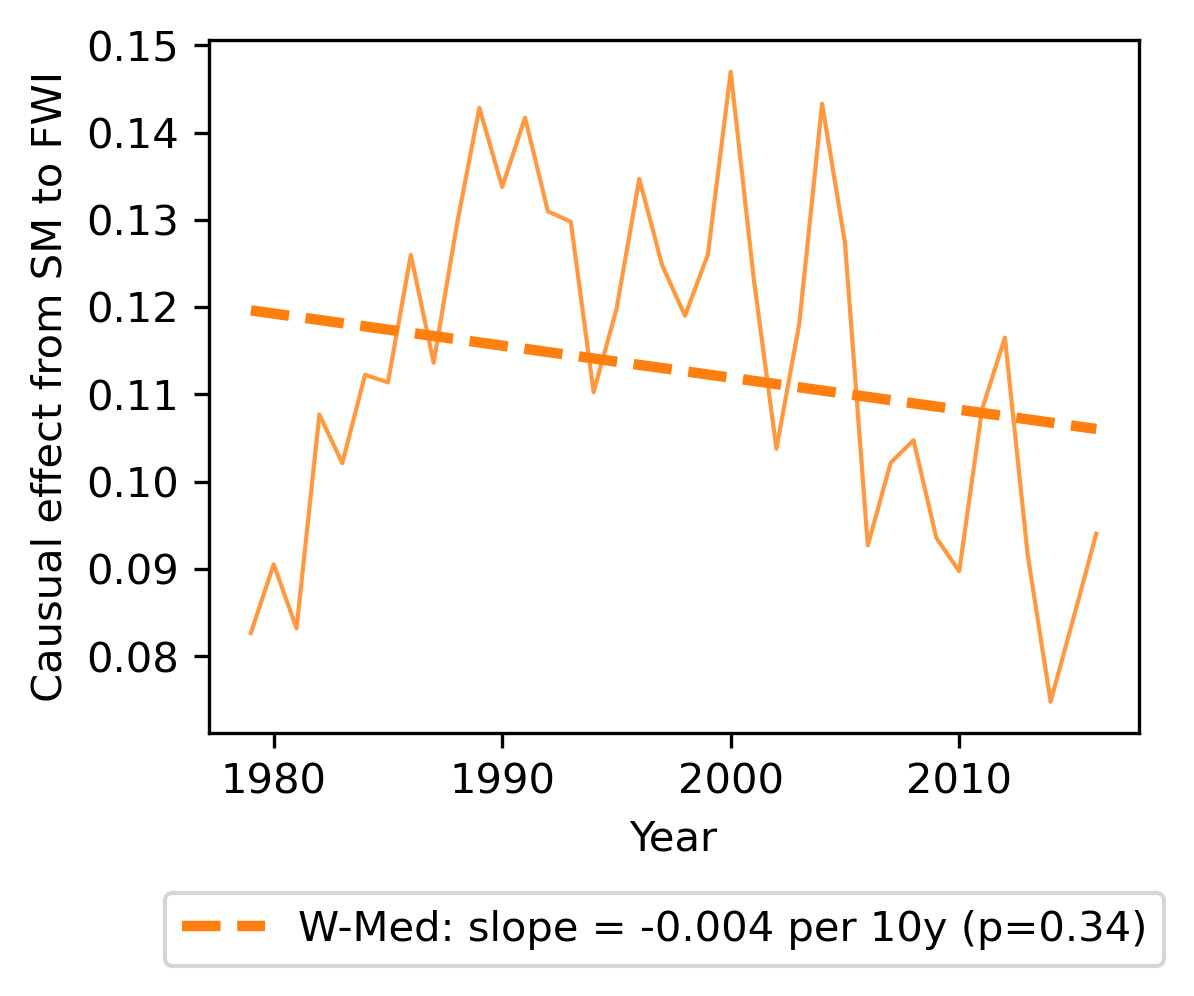

In [ ]:
annual_means = SM_links_strength
annual_bs = SM_links_strength_bs
years = np.arange(1979, 2017)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)



for k,k_name in enumerate(['W-Med_']):

    ax.plot(
        years,
        -annual_means[k_name],
        color=cluster_colors[k_name],
        lw=1.,
        alpha=0.8,
        # label=cluster_names_plot [k_name]
    )

    # ax.axhspan(-np.nanpercentile(annual_bs[k_name],5),-np.nanpercentile(annual_bs[k_name],95),alpha=0.2,color=cluster_colors[k_name])


for k,k_name in enumerate(['W-Med_']):
    y = -annual_means[k_name]
    mask = (~np.isnan(y))&(years>=1979)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    

    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years[mask]

    slope,p,ci=block_sig(years[mask],y[mask],block=5)
    
    ax.plot(
        years[mask],
        trend,
        color=cluster_colors[k_name],
        lw=2.5,
        linestyle="--",
        label = f"{cluster_names_plot [k_name]}: " + f"slope = {slope*10:.3f} per 10y (p={p:.2f})" 
    )

    print(
        f"{cluster_names_plot [k_name]}: "
        f"slope = {slope:.3f} /yr "
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )


ax.set_xlabel('Year')
ax.set_ylabel('Causual effect from SM to FWI')
plt.legend(bbox_to_anchor=(1.05,-0.2))

### Z500_links_strength

In [90]:
cluster_name_all

['W-Med_', 'C-Med_', 'E-Med_']

W-Med: slope = -0.001 /yr (95% CI [-0.002, -0.000])
C-Med: slope = 0.001 /yr (95% CI [0.001, 0.002])
E-Med: slope = -0.000 /yr (95% CI [-0.001, 0.000])


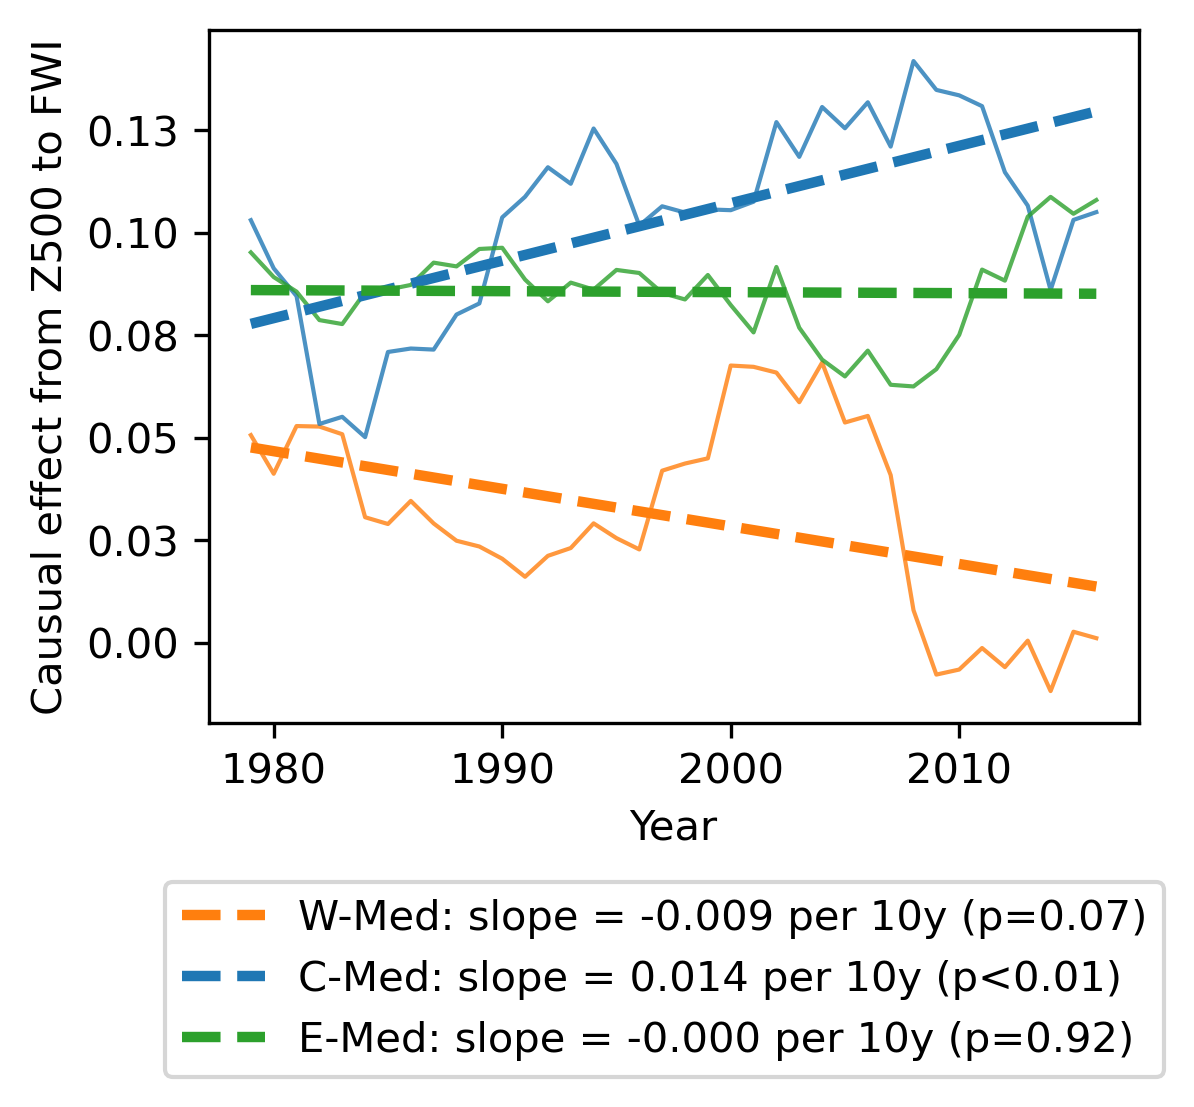

In [ ]:
annual_means = Z500_links_strength
annual_bs = Z500_links_strength_bs

years = np.arange(1979, 2017)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)



for k,k_name in enumerate(['W-Med_','C-Med_', 'E-Med_']):

    ax.plot(
        years,
        annual_means[k_name],
        color=cluster_colors[k_name],
        lw=1.,
        alpha=0.8,
        # label=cluster_names_plot [k_name]
    )
    # ax.axhspan(np.nanpercentile(annual_bs[k_name],5),np.nanpercentile(annual_bs[k_name],95),alpha=0.2,color=cluster_colors[k_name])


for k,k_name in enumerate(['W-Med_','C-Med_', 'E-Med_']):
    y = annual_means[k_name]
    mask = (~np.isnan(y))&(years>=1979)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    

    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years[mask]
    slope,p,ci=block_sig(years[mask],y[mask],block=5)
    if p<0.01:
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k_name],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names_plot [k_name]}: " + f"slope = {slope*10:.3f} per 10y (p<0.01)" 
        )
    else:
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k_name],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names_plot [k_name]}: " + f"slope = {slope*10:.3f} per 10y (p={p:.2f})" 
        )
    print(
        f"{cluster_names_plot [k_name]}: "
        f"slope = {slope:.3f} /yr "
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )

from matplotlib.ticker import FormatStrFormatter
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_xlabel('Year')
ax.set_ylabel('Causual effect from Z500 to FWI')
plt.legend(bbox_to_anchor=(1.05,-0.2))

### FWI_links

W-Med: slope = -0.002 /yr (95% CI [-0.004, -0.000])
C-Med: slope = 0.001 /yr (95% CI [-0.001, 0.002])
E-Med: slope = 0.003 /yr (95% CI [0.001, 0.004])


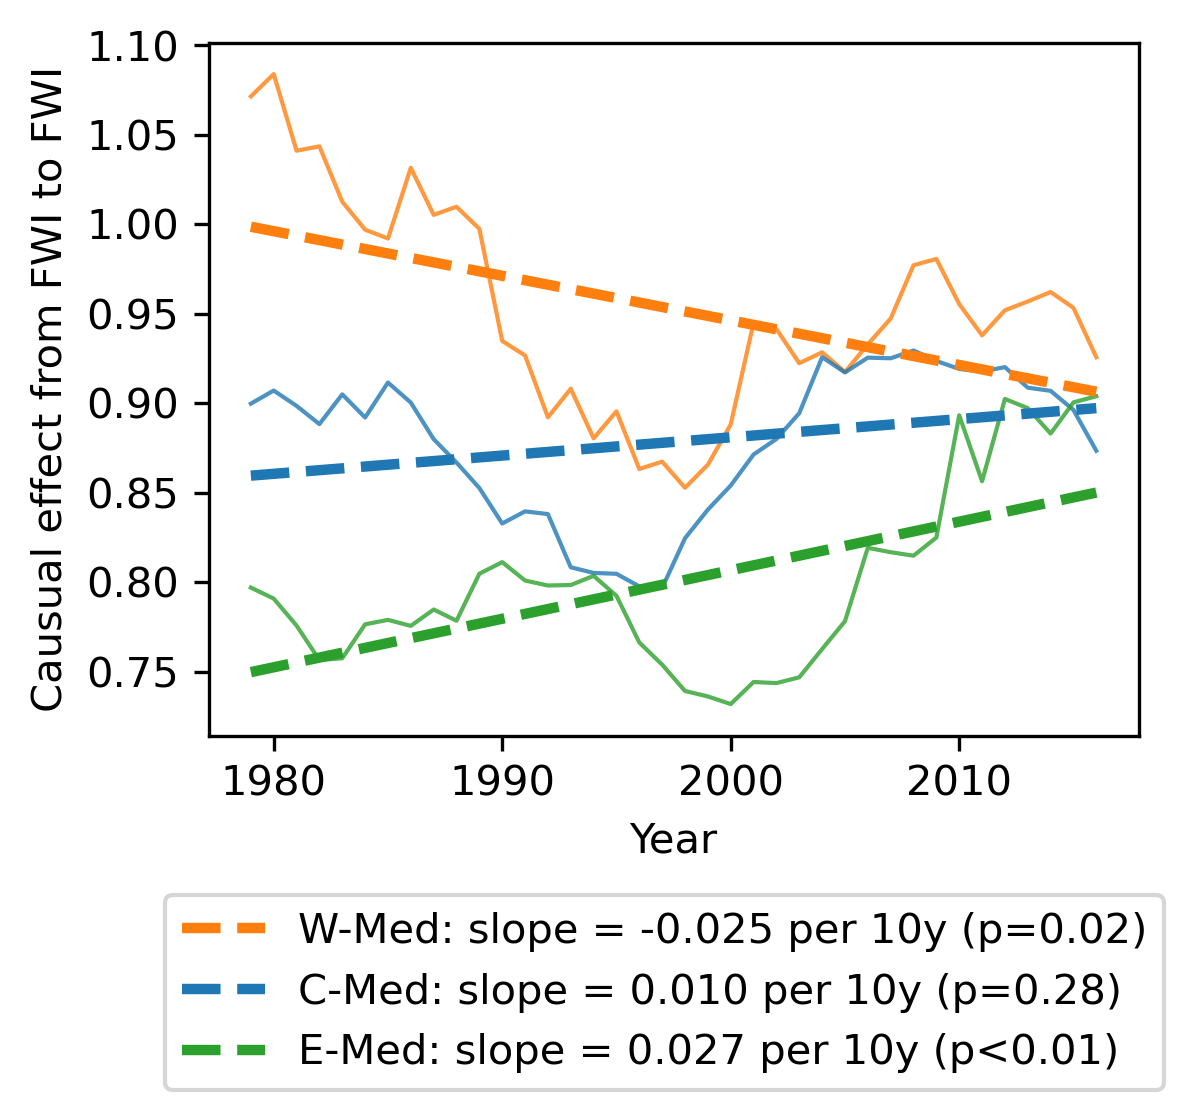

In [ ]:
annual_means = FWI_links_strength
annual_bs = FWI_links_strength_bs

years = np.arange(1979, 2017)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)



for k,k_name in enumerate(cluster_name_all):

    ax.plot(
        years,
        annual_means[k_name],
        color=cluster_colors[k_name],
        lw=1.,
        alpha=0.8,
        # label=cluster_names_plot [k_name]
    )
    # ax.axhspan(np.nanpercentile(annual_bs[k_name],5),np.nanpercentile(annual_bs[k_name],95),alpha=0.2,color=cluster_colors[k_name])

for k,k_name in enumerate(cluster_name_all):
    y = annual_means[k_name]
    mask = (~np.isnan(y))&(years>=1979)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    

    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years[mask]
    slope,p,ci=block_sig(years[mask],y[mask],block=5)
    if p<0.01:
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k_name],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names_plot [k_name]}: " + f"slope = {slope*10:.3f} per 10y (p<0.01)" 
        )
    else:
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k_name],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names_plot [k_name]}: " + f"slope = {slope*10:.3f} per 10y (p={p:.2f})" 
        )        

    print(
        f"{cluster_names_plot [k_name]}: "
        f"slope = {slope:.3f} /yr "
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )


ax.set_xlabel('Year')
ax.set_ylabel('Causual effect from FWI to FWI')
plt.legend(bbox_to_anchor=(1.05,-0.2))

## Etesians

E-Med: slope = 0.001 /yr (95% CI [0.000, 0.002])


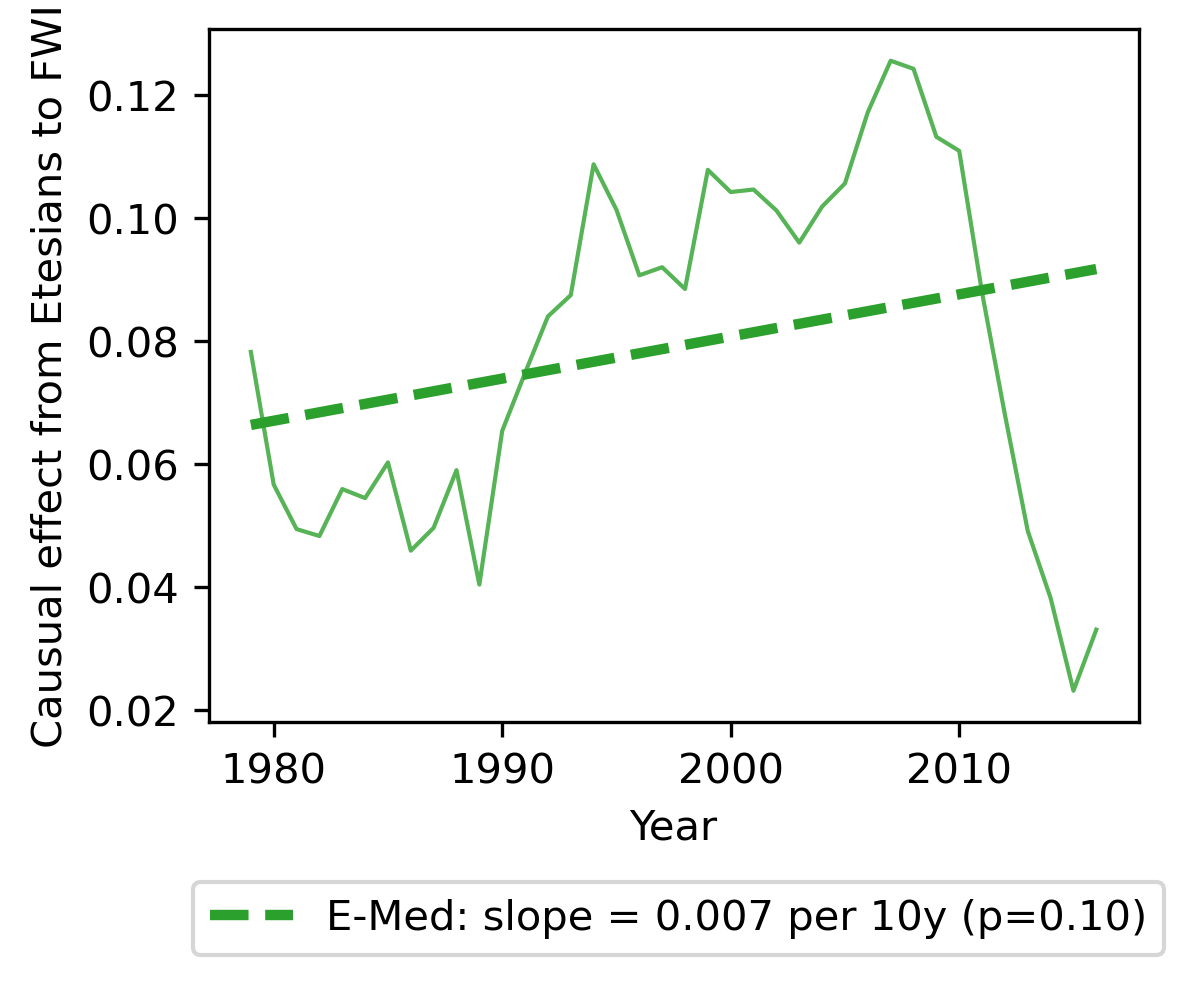

In [ ]:
annual_means =Etesians_links_strength
annual_bs = Etesians_links_strength_bs

years = np.arange(1979, 2017)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)



for k,k_name in enumerate(['E-Med_']):

    ax.plot(
        years,
        annual_means[k_name],
        color=cluster_colors[k_name],
        lw=1.,
        alpha=0.8,
        # label=cluster_names_plot [k_name]
    )
    # ax.axhspan(np.nanpercentile(annual_bs[k_name],5),np.nanpercentile(annual_bs[k_name],95),alpha=0.2,color=cluster_colors[k_name])

for k,k_name in enumerate(['E-Med_']):
    y = annual_means[k_name]
    mask = (~np.isnan(y))&(years>=1979)

    slope, intercept, lo, hi = theilslopes(
        y[mask], years[mask], 0.95
    )

    

    slope, intercept, r, p, stderr = linregress( years[mask],y[mask])
    trend = intercept + slope * years[mask]
    slope,p,ci=block_sig(years[mask],y[mask],block=5)
    if p<0.01:
            
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k_name],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names_plot [k_name]}: " + f"slope = {slope*10:.3f} per 10y (p<0.01)" 
        )
    else:
        ax.plot(
            years[mask],
            trend,
            color=cluster_colors[k_name],
            lw=2.5,
            linestyle="--",
            label = f"{cluster_names_plot [k_name]}: " + f"slope = {slope*10:.3f} per 10y (p={p:.2f})" 
        )    

    print(
        f"{cluster_names_plot [k_name]}: "
        f"slope = {slope:.3f} /yr "
        f"(95% CI [{lo:.3f}, {hi:.3f}])"
    )


ax.set_xlabel('Year')
ax.set_ylabel('Causual effect from Etesians to FWI')
plt.legend(bbox_to_anchor=(1.05,-0.2))